In [1]:
import cellxgene_census
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

# Import functions from local modules
from evaluation import (
    generate_celltype_summary,
    generate_llm_summary,
    load_and_prepare_results,
    make_umaps_for_obsm,
    plot_comparison_matrix,
    plot_overall_performance,
    plot_pairwise_comparison,
)
from single_prediction_task import run_benchmark, run_cv_experiment

emb_names = [
    "scvi",
    "geneformer",
    "tf-sapiens",
    "tf-exemplar-human",
]
census_version = "2025-01-30"

# "scgpt", "uce", "nmf" not available for this version of census

/Users/dmichael/.envs/targets/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
with cellxgene_census.open_soma(census_version=census_version) as census:
    print(census["census_data"]["homo_sapiens"].obs.keys())

('soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars')


In [3]:
with cellxgene_census.open_soma(census_version=census_version) as census:
    samples_df = (
        census["census_data"]["homo_sapiens"]
        .obs.read(
            value_filter="is_primary_data==True",
            column_names=[
                "dataset_id",
                "assay",
                "suspension_type",
                "cell_type",
                "donor_id",
                "disease",
                "tissue",
                "tissue_type",
                "tissue_general",
                "nnz",
            ],
        )
        .concat()
        .to_pandas()
    )

[]

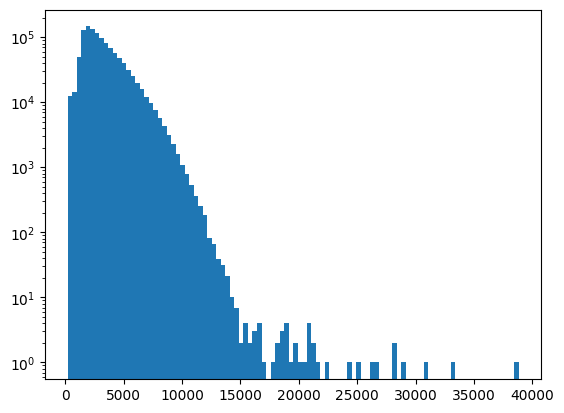

In [4]:
_ = plt.hist(
    samples_df[(samples_df.dataset_id == "53d208b0-2cfd-4366-9866-c3c6114081bc")].nnz,
    bins=100,
)
plt.semilogy()

In [5]:
# --- Filter samples_df down to (dataset_id, cell_type[, tissue]) groups that support donor-level disease prediction ---
# Criteria:
#   1) >1 disease value present
#   2) For EACH disease value, >=3 unique donors

group_cols = [
    "dataset_id",
    "cell_type",
]  # add "tissue" (or "tissue_general") here if you want to stratify by tissue too

# Donors per disease inside each group
donors_per_disease = (
    samples_df.groupby(group_cols + ["disease"], observed=True)["donor_id"]
    .nunique()
    .rename("n_donors")
    .reset_index()
)

# Groups that have >=2 donors for every disease they contain
eligible_groups = (
    donors_per_disease.groupby(group_cols, observed=True)["n_donors"]
    .min()
    .rename("min_donors_per_disease")
    .reset_index()
    .query("min_donors_per_disease >= 3")
)

# Also require >1 disease value present in the group
disease_counts = (
    samples_df.groupby(group_cols, observed=True)["disease"]
    .nunique()
    .rename("n_diseases")
    .reset_index()
    .query("n_diseases >= 2")
)

# Final eligible (dataset, cell_type) groups
eligible = (
    eligible_groups.merge(disease_counts, on=group_cols, how="inner")
    .sort_values(["n_diseases", "min_donors_per_disease"], ascending=False)
    .reset_index(drop=True)
)

# Optional: attach details you’ll likely want for routing jobs / sanity checking
details = (
    samples_df.groupby(group_cols + ["disease"], observed=True)
    .agg(
        n_cells=("donor_id", "size"),
        n_donors=("donor_id", "nunique"),
        nnz_median=("nnz", "median"),
        nnz_mean=("nnz", "mean"),
    )
    .reset_index()
)

eligible_with_details = eligible.merge(details, on=group_cols, how="left")

# What you asked for: "a list of datasets and diseases"
# This gives you one row per eligible (dataset_id, cell_type) with the disease set available.
eligible_disease_sets = (
    samples_df.merge(eligible[group_cols], on=group_cols, how="inner")
    .groupby(group_cols, observed=True)["disease"]
    .apply(lambda s: sorted(pd.unique(s.astype(str))))
    .rename("diseases")
    .reset_index()
    .merge(eligible, on=group_cols, how="left")
    .sort_values(["n_diseases", "min_donors_per_disease"], ascending=False)
    .reset_index(drop=True)
)

# Outputs:
# - eligible: eligible (dataset_id, cell_type) groups with n_diseases and min donors per disease
# - eligible_disease_sets: same, plus explicit disease list per group
# - eligible_with_details: expanded view with per-disease donor/cell counts for each eligible group

print(f"Eligible groups: {len(eligible)}")
display(eligible_disease_sets.head(25))
# display(eligible_with_details)  # uncomment if you want the long-form per-disease breakdown

Eligible groups: 1032


,dataset_id,cell_type,diseases,min_donors_per_disease,n_diseases
0,7b20c613-9add-43d1-87e9-defd3d9b9f8c,malignant cell,"[HER2 positive breast carcinoma, basal cell ca...",4,7
1,6a270451-b4d9-43e0-aa89-e33aac1ac74b,plasma cell,"[colon sessile serrated adenoma/polyp, colorec...",4,6
2,6a270451-b4d9-43e0-aa89-e33aac1ac74b,T cell,"[colon sessile serrated adenoma/polyp, colorec...",3,6
3,6a270451-b4d9-43e0-aa89-e33aac1ac74b,myeloid cell,"[colon sessile serrated adenoma/polyp, colorec...",3,6
4,7b20c613-9add-43d1-87e9-defd3d9b9f8c,T cell,"[HER2 positive breast carcinoma, basal cell ca...",4,5
5,7b20c613-9add-43d1-87e9-defd3d9b9f8c,endothelial cell,"[HER2 positive breast carcinoma, basal cell ca...",3,5
6,4a5b00e0-1ba3-4fd4-af89-d3512eb20720,B cell,"[hematologic disorder, myelodysplastic syndrom...",10,4
7,4a5b00e0-1ba3-4fd4-af89-d3512eb20720,hematopoietic multipotent progenitor cell,"[hematologic disorder, myelodysplastic syndrom...",10,4
8,4a5b00e0-1ba3-4fd4-af89-d3512eb20720,hematopoietic precursor cell,"[hematologic disorder, myelodysplastic syndrom...",10,4
9,4a5b00e0-1ba3-4fd4-af89-d3512eb20720,unknown,"[hematologic disorder, myelodysplastic syndrom...",10,4


In [6]:
eligible_with_details.disease.astype(str).value_counts()

disease
normal                    938
COVID-19                  286
Crohn disease              80
acute kidney failure       71
chronic kidney disease     71
                         ... 
temporal lobe epilepsy      2
localized scleroderma       1
keloid                      1
injury                      1
melanoma                    1
Name: count, Length: 69, dtype: int64

In [7]:
samples_df[
    samples_df.dataset_id.isin(
        eligible_with_details.groupby("dataset_id", observed=True).count().index
    )
].groupby("dataset_id", observed=True).count().sort_values("nnz")

,assay,suspension_type,cell_type,donor_id,disease,tissue,tissue_type,tissue_general,nnz,is_primary_data
dataset_id,,,,,,,,,,
2856d06c-0ff9-4e01-bfc9-202b74d0b60f,6364,6364,6364,6364,6364,6364,6364,6364,6364,6364
f5be4b96-f5a3-4c3d-84ac-6f69daf744d5,6811,6811,6811,6811,6811,6811,6811,6811,6811,6811
4dd1cd23-fc4d-4fd1-9709-602540f3ca6f,7825,7825,7825,7825,7825,7825,7825,7825,7825,7825
6a270451-b4d9-43e0-aa89-e33aac1ac74b,10696,10696,10696,10696,10696,10696,10696,10696,10696,10696
a1b9c51e-a408-4f7f-bccb-abefe20ae2a5,16245,16245,16245,16245,16245,16245,16245,16245,16245,16245
...,...,...,...,...,...,...,...,...,...,...
c2876b1b-06d8-4d96-a56b-5304f815b99a,1149751,1149751,1149751,1149751,1149751,1149751,1149751,1149751,1149751,1149751
218acb0f-9f2f-4f76-b90b-15a4b7c7f629,1263676,1263676,1263676,1263676,1263676,1263676,1263676,1263676,1263676,1263676
6f7fd0f1-a2ed-4ff1-80d3-33dde731cbc3,1309414,1309414,1309414,1309414,1309414,1309414,1309414,1309414,1309414,1309414


In [8]:
samples_df.query('cell_type == "pancreatic A cell"').groupby(
    ["dataset_id", "disease", "donor_id"], observed=True
).count()

assay  \
dataset_id                           disease                  donor_id                              
31f657dc-1875-4c4b-a5ca-ce63b3ef3a82 normal                   AFES365                         387   
                                                              AFES448                         280   
                                                              TUM_13                           19   
                                                              TUM_25                          128   
                                                              TUM_C1                           26   
3294d050-6eeb-4a00-b24c-71aacc9b777f normal                   R229                           1484   
                                                              R237                           1650   
                                                              R239                           2397   
                                                              R245                           2083   
                                                              R266                           3927   
37b21763-7f0f-41ae-9001-60bad6e2841d normal                   HPAP019                         202   
                                                              HPAP022                        1734   
                                                              HPAP024                          53   
                                                              HPAP026                          96   
                                                              HPAP029                          90   
                                                              HPAP034                          56   
                                                              HPAP035                         653   
                                                              HPAP036                         625   
                                                              HPAP037                         414   
                                                              HPAP038                         763   
                                                              HPAP039                          54   
                                                              HPAP040                        1026   
                                                              HPAP042                          49   
                                                              HPAP043                          89   
                                                              HPAP044                          58   
                                                              HPAP045                        1452   
                                                              HPAP047                          56   
                                                              HPAP049                        1404   
                                                              HPAP050                         988   
                                     type 1 diabetes mellitus HPAP020                         629   
                                                              HPAP021                         330   
                                                              HPAP023                          17   
                                                              HPAP028                         723   
                                                              HPAP032                          28   
53d208b0-2cfd-4366-9866-c3c6114081bc normal                   TSP1                             48   
6725ee8e-ef5b-4e68-8901-61bd14a1fe73 normal                   Hein_Dev_2022_Spheroids           1   
                                                              Li_StemCR_2020_Stage5            24   
                                                              Li_StemCR_2020_Stage6            19   
                                                    

In [9]:
import os

import cellxgene_census


def load_or_prepare_adata(
    dataset_id: str,
    census_version: str,
    embedding_keys: list[str],
    census_uri: str | None = None,
    cache_dir: str = "./cache",
    force_recompute: bool = False,
):
    """Load preprocessed dataset from disk, or download + preprocess once."""
    os.makedirs(cache_dir, exist_ok=True)
    cache_path = os.path.join(
        cache_dir,
        f"dataset_{dataset_id}_census_{census_version}.h5ad",
    )

    if os.path.exists(cache_path) and not force_recompute:
        print(f"Loading cached dataset from {cache_path}")
        return sc.read_h5ad(cache_path)

    print(f"Downloading + preprocessing dataset {dataset_id}")

    obs_filter = f"is_primary_data==True and dataset_id=='{dataset_id}'"

    with cellxgene_census.open_soma(
        uri=census_uri, census_version=census_version
    ) as census:
        adata = cellxgene_census.get_anndata(
            census=census,
            organism="homo_sapiens",
            measurement_name="RNA",
            obs_value_filter=obs_filter,
            obs_column_names=["cell_type", "donor_id", "disease"],
            obs_embeddings=embedding_keys,
        )

    adata.write_h5ad(cache_path)

    print(f"Cached dataset written to {cache_path}")
    return adata

In [10]:
op_datasets = {
    "Diabetic Kidney Disease": "e067e5ca-e53e-485f-aa8e-efd5435229c8",
    "GTEX v9": "4ed927e9-c099-49af-b8ce-a2652d069333",
    "HypoMap": "dbb4e1ed-d820-4e83-981f-88ef7eb55a35",
    "Immune Cell Atlas": "1b9d8702-5af8-4142-85ed-020eb06ec4f6",  # Global
    # "Mouse Pancreatic Islet Atlas": "49e4ffcc-5444-406d-bdee-577127404ba8",
    "Tabula Sapiens": "53d208b0-2cfd-4366-9866-c3c6114081bc",  # All Cells
    # h5ad link "Tabula Sapiens - Mammary":"95aa14c9-5226-48ae-bd6c-eb901fb5af7e"
    "Tabula Sapiens - Mammary": "2ba40233-8576-4dec-a5f1-2adfa115e2dc",
    "HPAP": "37b21763-7f0f-41ae-9001-60bad6e2841d",
}

In [11]:
dataset_id = "8e47ed12-c658-4252-b126-381df8d52a3d"
dataset_id = "5e717147-0f75-4de1-8bd2-6fda01b8d75f"
for dataset_id in op_datasets.values():
    load_or_prepare_adata(
        dataset_id,
        census_version="2025-01-30",
        embedding_keys=emb_names,
        census_uri=None,
        cache_dir="/Users/dmichael/bmfm-targets/cache/",
        force_recompute=False,
    )

Loading cached dataset from /Users/dmichael/bmfm-targets/cache/dataset_e067e5ca-e53e-485f-aa8e-efd5435229c8_census_2025-01-30.h5ad
Loading cached dataset from /Users/dmichael/bmfm-targets/cache/dataset_4ed927e9-c099-49af-b8ce-a2652d069333_census_2025-01-30.h5ad
Loading cached dataset from /Users/dmichael/bmfm-targets/cache/dataset_dbb4e1ed-d820-4e83-981f-88ef7eb55a35_census_2025-01-30.h5ad
Loading cached dataset from /Users/dmichael/bmfm-targets/cache/dataset_1b9d8702-5af8-4142-85ed-020eb06ec4f6_census_2025-01-30.h5ad
Loading cached dataset from /Users/dmichael/bmfm-targets/cache/dataset_53d208b0-2cfd-4366-9866-c3c6114081bc_census_2025-01-30.h5ad
Loading cached dataset from /Users/dmichael/bmfm-targets/cache/dataset_2ba40233-8576-4dec-a5f1-2adfa115e2dc_census_2025-01-30.h5ad
Loading cached dataset from /Users/dmichael/bmfm-targets/cache/dataset_37b21763-7f0f-41ae-9001-60bad6e2841d_census_2025-01-30.h5ad


In [12]:
adata_hpap = load_or_prepare_adata(
    op_datasets["HPAP"],
    census_version="2025-01-30",
    embedding_keys=emb_names,
    census_uri=None,
    cache_dir="/Users/dmichael/bmfm-targets/cache/",
    force_recompute=False,
)

Loading cached dataset from /Users/dmichael/bmfm-targets/cache/dataset_37b21763-7f0f-41ae-9001-60bad6e2841d_census_2025-01-30.h5ad


In [13]:
adata_hpap = adata_hpap[
    adata_hpap.obs.query('cell_type == "pancreatic A cell"').index
].copy()
for en in emb_names:
    print(en, adata_hpap.obsm[en].shape)
print(type(adata_hpap.X))
print(adata_hpap.X.shape)
adata_hpap.obs.groupby(["disease", "donor_id"], observed=True).count().iloc[:, 0]

scvi (11589, 50)
geneformer (11589, 512)
tf-sapiens (11589, 2048)
tf-exemplar-human (11589, 2048)
<class 'scipy.sparse._csr.csr_matrix'>
(11589, 61888)


disease                   donor_id
normal                    HPAP019      202
                          HPAP022     1734
                          HPAP024       53
                          HPAP026       96
                          HPAP029       90
                          HPAP034       56
                          HPAP035      653
                          HPAP036      625
                          HPAP037      414
                          HPAP038      763
                          HPAP039       54
                          HPAP040     1026
                          HPAP042       49
                          HPAP043       89
                          HPAP044       58
                          HPAP045     1452
                          HPAP047       56
                          HPAP049     1404
                          HPAP050      988
type 1 diabetes mellitus  HPAP020      629
                          HPAP021      330
                          HPAP023       17
                   

In [15]:
fold_df, summary_df, winners_df, folds, counts = run_benchmark(
    adata_hpap,
    embedding_keys=emb_names,
    include_raw_lognorm=True,
    include_raw_lognorm_plus_binary=False,
    include_raw_hvg512=False,
    include_raw_best_pca=True,
    pca_components_grid=(20, 50, 100),
)
print(summary_df)
display(winners_df)
display(fold_df.sort_values(["feature", "fold"]))

Donor-pair benchmark:   0%|          | 0/30 [00:00<?, ?fit/s]

/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1037101083.py:73: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))
/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1037101083.py:73: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))
/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1037101083.py:73: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))
/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1037101083.py:73: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))
/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1037101083.py:73: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))
/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1037101083.py:73: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-z))
/var/folders/xt/l7g716w17kb53w9c8k

                            feature  folds  AUROC_mean  AUPRC_mean  \
0        X lognorm (nz 23909/61888)      5    0.888080    0.811263   
3               obsm[scvi] (zscore)      5    0.885262    0.802920   
2         obsm[geneformer] (zscore)      5    0.877198    0.792935   
1           X lognorm + PCA50 (SVD)      5    0.863419    0.799366   
5         obsm[tf-sapiens] (zscore)      5    0.776108    0.766659   
4  obsm[tf-exemplar-human] (zscore)      5    0.710894    0.763911   

   balanced_acc_mean   F1_mean  MCC_mean  log_loss_mean  brier_mean  \
0           0.630183  0.356282  0.321123       7.158491    0.318449   
3           0.726431  0.661163  0.499643       5.836780    0.307226   
2           0.759729  0.661863  0.561183       7.269220    0.214165   
1           0.723606  0.581090  0.496858       6.097993    0.229581   
5           0.686468  0.617548  0.429964      10.361051    0.291630   
4           0.584892  0.426271  0.244654      12.846516    0.363881   

   elapsed_

,fold,winner_feature,MCC,AUROC,AUPRC,balanced_acc,F1,elapsed_s,diseased_donor,healthy_donor
0,0,X lognorm + PCA50 (SVD),0.738186,0.991089,0.990066,0.856085,0.834097,0.033236,HPAP020,HPAP036
1,1,obsm[scvi] (zscore),0.755142,0.971036,0.968209,0.857905,0.835355,0.028895,HPAP021,HPAP037
2,2,obsm[tf-sapiens] (zscore),0.840828,0.939976,0.912656,0.882353,0.866667,0.195984,HPAP023,HPAP042
3,3,obsm[scvi] (zscore),0.482778,0.964469,0.962194,0.686758,0.544724,0.016368,HPAP028,HPAP038
4,4,X lognorm (nz 23909/61888),0.865780,0.984694,0.980124,0.941327,0.915254,0.429514,HPAP032,HPAP042


,AUROC,AUPRC,balanced_acc,F1,MCC,log_loss,brier,TP,FP,TN,FN,test_pos_rate,feature,fold,disease_left_out,diseased_donor,healthy_donor,n_train,n_test,elapsed_s
4,0.936864,0.909729,0.609632,0.380832,0.325160,8.057712,0.383914,151,13,612,478,0.501595,X lognorm (nz 23909/61888),0,type 1 diabetes mellitus,HPAP020,HPAP036,10335,1254,0.396186
10,0.686400,0.594053,0.521585,0.144772,0.091908,10.654164,0.423703,27,16,398,303,0.443548,X lognorm (nz 23909/61888),1,type 1 diabetes mellitus,HPAP021,HPAP037,10845,744,0.437257
16,0.842737,0.584286,0.557623,0.260870,0.175306,2.609058,0.255581,3,3,46,14,0.257576,X lognorm (nz 23909/61888),2,type 1 diabetes mellitus,HPAP023,HPAP042,11523,66,0.573927
22,0.989707,0.988121,0.520747,0.079681,0.147460,13.747256,0.464753,30,0,763,693,0.486541,X lognorm (nz 23909/61888),3,type 1 diabetes mellitus,HPAP028,HPAP038,10103,1486,0.402417
28,0.984694,0.980124,0.941327,0.915254,0.865780,0.724265,0.064294,27,4,45,1,0.363636,X lognorm (nz 23909/61888),4,type 1 diabetes mellitus,HPAP032,HPAP042,11512,77,0.429514
5,0.991089,0.990066,0.856085,0.834097,0.738186,2.515512,0.139220,455,7,618,174,0.501595,X lognorm + PCA50 (SVD),0,type 1 diabetes mellitus,HPAP020,HPAP036,10335,1254,0.033236
11,0.975106,0.961687,0.674857,0.521158,0.473977,5.962206,0.283400,117,2,412,213,0.443548,X lognorm + PCA50 (SVD),1,type 1 diabetes mellitus,HPAP021,HPAP037,10845,744,0.028817
17,0.506603,0.267134,0.487395,0.153846,-0.032125,9.725150,0.335418,2,7,42,15,0.257576,X lognorm + PCA50 (SVD),2,type 1 diabetes mellitus,HPAP023,HPAP042,11523,66,0.020193
23,0.879284,0.890107,0.658368,0.481092,0.438473,11.140434,0.330703,229,0,763,494,0.486541,X lognorm + PCA50 (SVD),3,type 1 diabetes mellitus,HPAP028,HPAP038,10103,1486,0.014269
29,0.965015,0.887836,0.941327,0.915254,0.865780,1.146661,0.059167,27,4,45,1,0.363636,X lognorm + PCA50 (SVD),4,type 1 diabetes mellitus,HPAP032,HPAP042,11512,77,0.017114


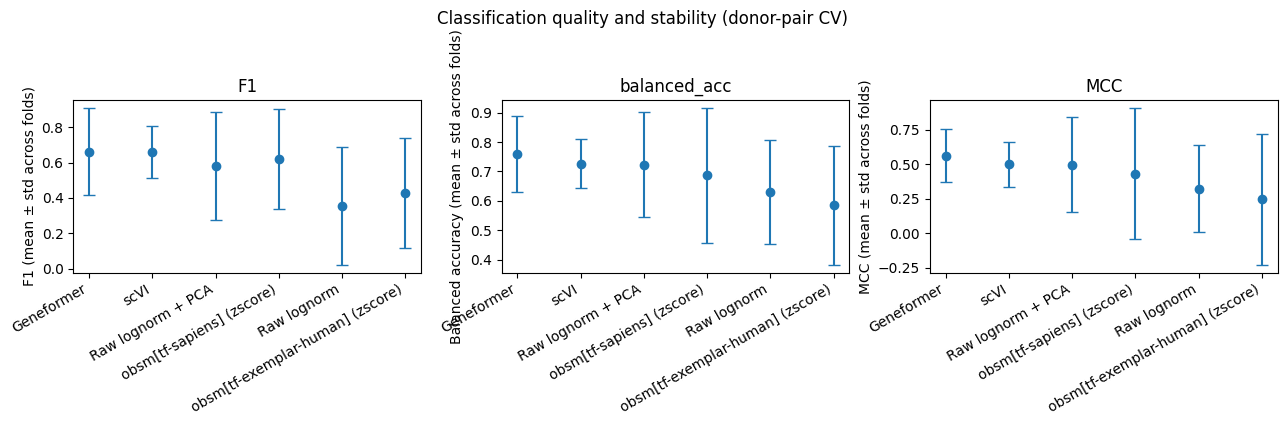

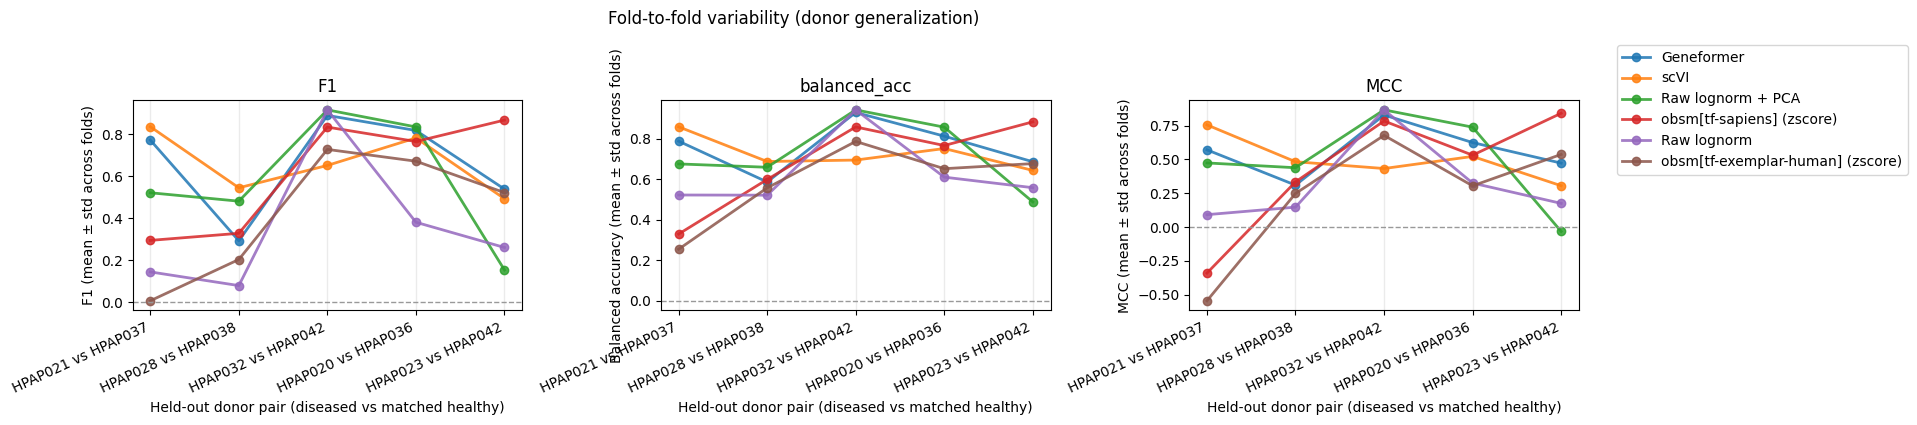

In [ ]:
# --- Run this AFTER your previous plotting block(s); uses fold_df already in memory ---

import matplotlib.pyplot as plt

df = fold_df.copy()

# Short labels (keep your axis rename improvement)
label_map = {
    "obsm[scvi] (zscore)": "scVI",
    "obsm[geneformer] (zscore)": "Geneformer",
    "X lognorm (nz 23909/61888)": "Raw lognorm",
    "X lognorm + PCA50 (SVD)": "Raw lognorm + PCA",
    "X lognorm + binary (nz 23909/61888)": "Raw lognorm + binary",
    "X HVG512 lognorm (nz 512/23909)": "Raw HVG512",
}
df["feature_short"] = df["feature"].map(label_map).fillna(df["feature"])

# Informative fold labels
df["fold_label"] = df.apply(
    lambda r: f"{r['diseased_donor']} vs {r['healthy_donor']}", axis=1
)

# Fix fold order using a stable reference (scVI AUROC descending)
ref = (
    df[df["feature_short"] == "scVI"]
    .sort_values(["AUROC", "fold"], ascending=[False, True])[
        ["fold", "fold_label", "AUROC"]
    ]
    .drop_duplicates("fold")
)
fold_order = ref["fold"].astype(int).tolist()
fold_labels = dict(zip(ref["fold"].astype(int), ref["fold_label"]))

df["fold"] = df["fold"].astype(int)
df = df[df["fold"].isin(fold_order)].copy()
df["fold_cat"] = pd.Categorical(df["fold"], categories=fold_order, ordered=True)
df["fold_name"] = df["fold_cat"].map(fold_labels)

# Feature order: by MCC mean (readable ordering across all plots)
feature_order = (
    df.groupby("feature_short")["MCC"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

# ------------------------
# Errorbar plots (mean ± std)
# ------------------------
metrics = [
    ("F1", "F1 (mean ± std across folds)"),
    ("balanced_acc", "Balanced accuracy (mean ± std across folds)"),
    ("MCC", "MCC (mean ± std across folds)"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=False)

for ax, (m, ylab) in zip(axes, metrics):
    summ = (
        df.groupby("feature_short")[m]
        .agg(["mean", "std"])
        .reindex(feature_order)
        .reset_index()
    )
    ax.errorbar(
        summ["feature_short"],
        summ["mean"],
        yerr=summ["std"],
        fmt="o",
        capsize=4,
    )
    ax.set_title(m)
    ax.set_ylabel(ylab)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    for tick in ax.get_xticklabels():
        tick.set_ha("right")

plt.suptitle("Classification quality and stability (donor-pair CV)", y=1.05)
plt.tight_layout()
plt.show()

# ------------------------
# Spaghetti plots (fold-by-fold) — no shading
# ------------------------
x_pos = np.arange(len(fold_order))
x_labels = [fold_labels[f] for f in fold_order]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for ax, (m, ylab) in zip(axes, metrics):
    for feat in feature_order:
        g = df[df["feature_short"] == feat].sort_values("fold_cat")
        ax.plot(
            x_pos,
            g[m].to_numpy(),
            marker="o",
            linewidth=2,
            alpha=0.85,
            label=feat,
        )

    ax.set_title(m)
    ax.set_ylabel(ylab)
    ax.set_xlabel("Held-out donor pair (diseased vs matched healthy)")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=25, ha="right")
    ax.axhline(0, color="0.6", lw=1, ls="--")
    # Light vertical guides to emphasize fold positions
    for x in x_pos:
        ax.axvline(x, color="0.92", lw=1, zorder=0)

# One legend for all
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="", bbox_to_anchor=(1.01, 0.98), loc="upper left")
plt.suptitle("Fold-to-fold variability (donor generalization)", y=1.05)
plt.tight_layout()
plt.show()

Automatic pdb calling has been turned ON
Loaded 25277 rows across 861 tasks
Features: ['Raw Log-norm', 'PCA-50', 'random_proj50', 'SCVI', 'GENEFORMER', 'TF-SAPIENS', 'TF-EXEMPLAR-HUMAN']


/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1789121523.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1789121523.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1789121523.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


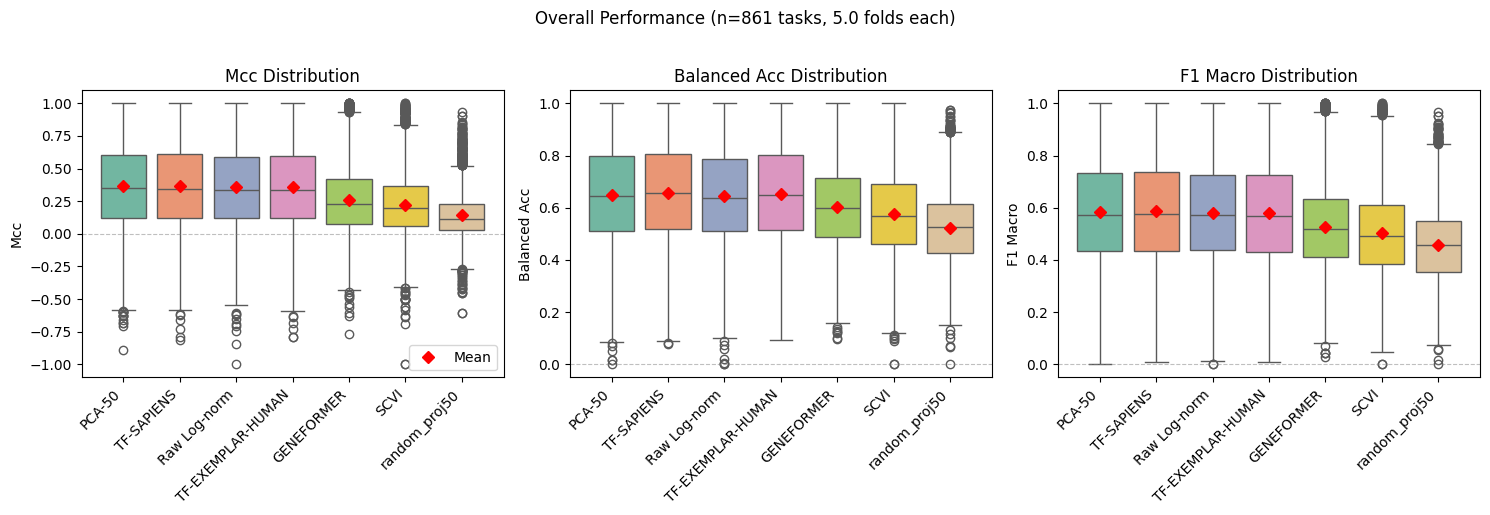

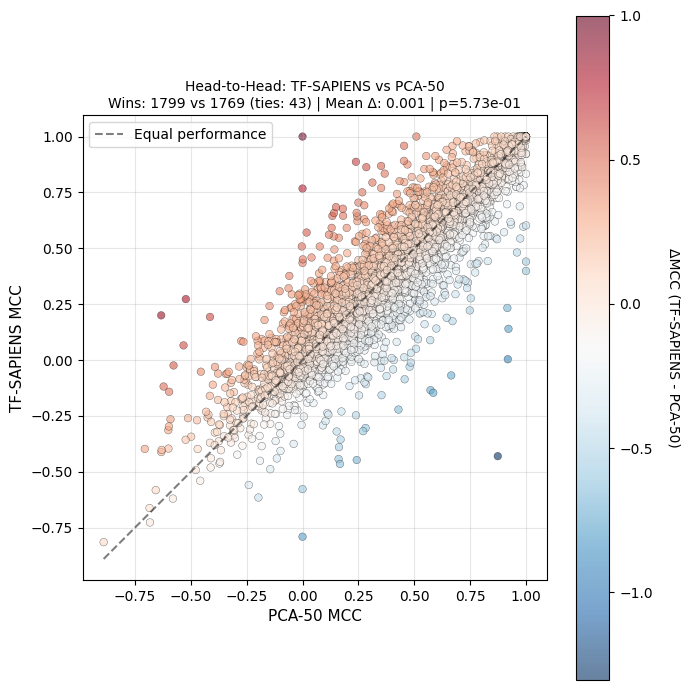

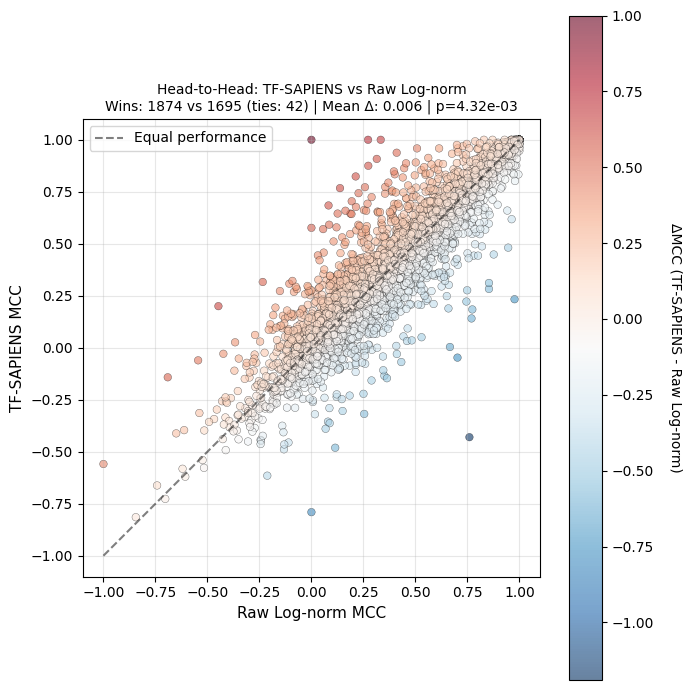

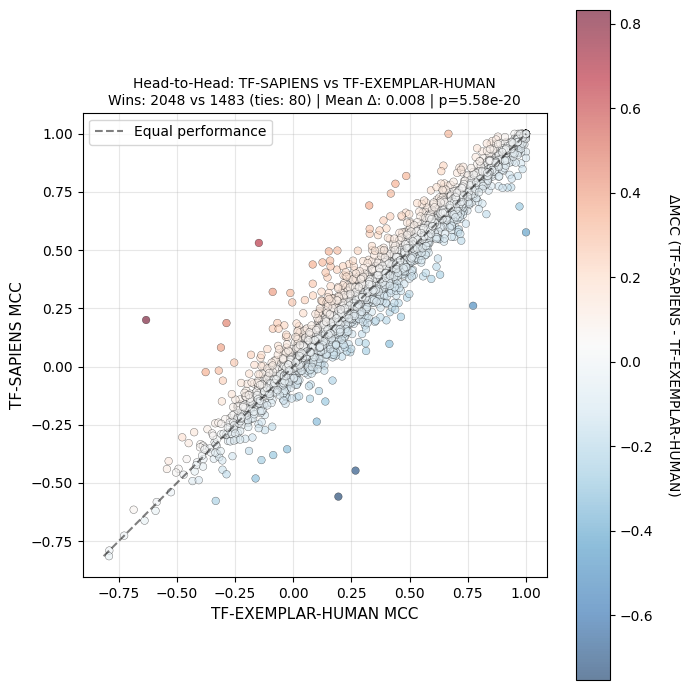

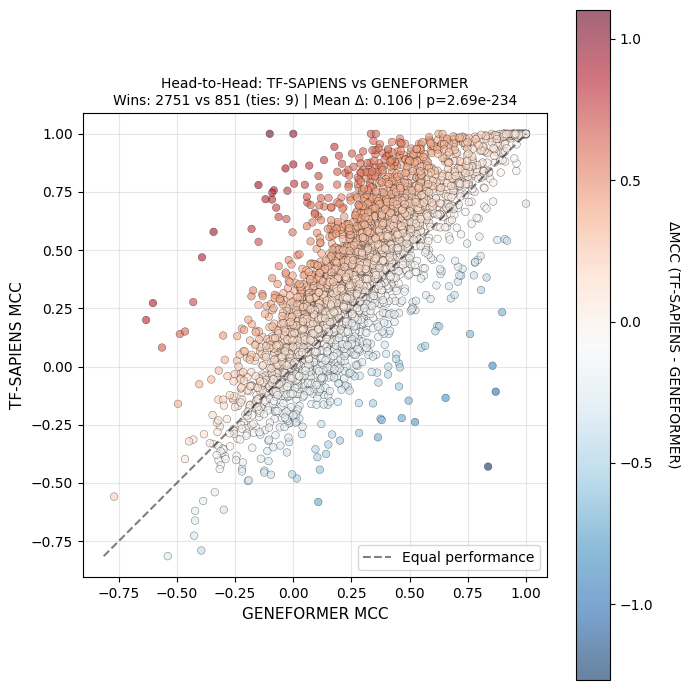

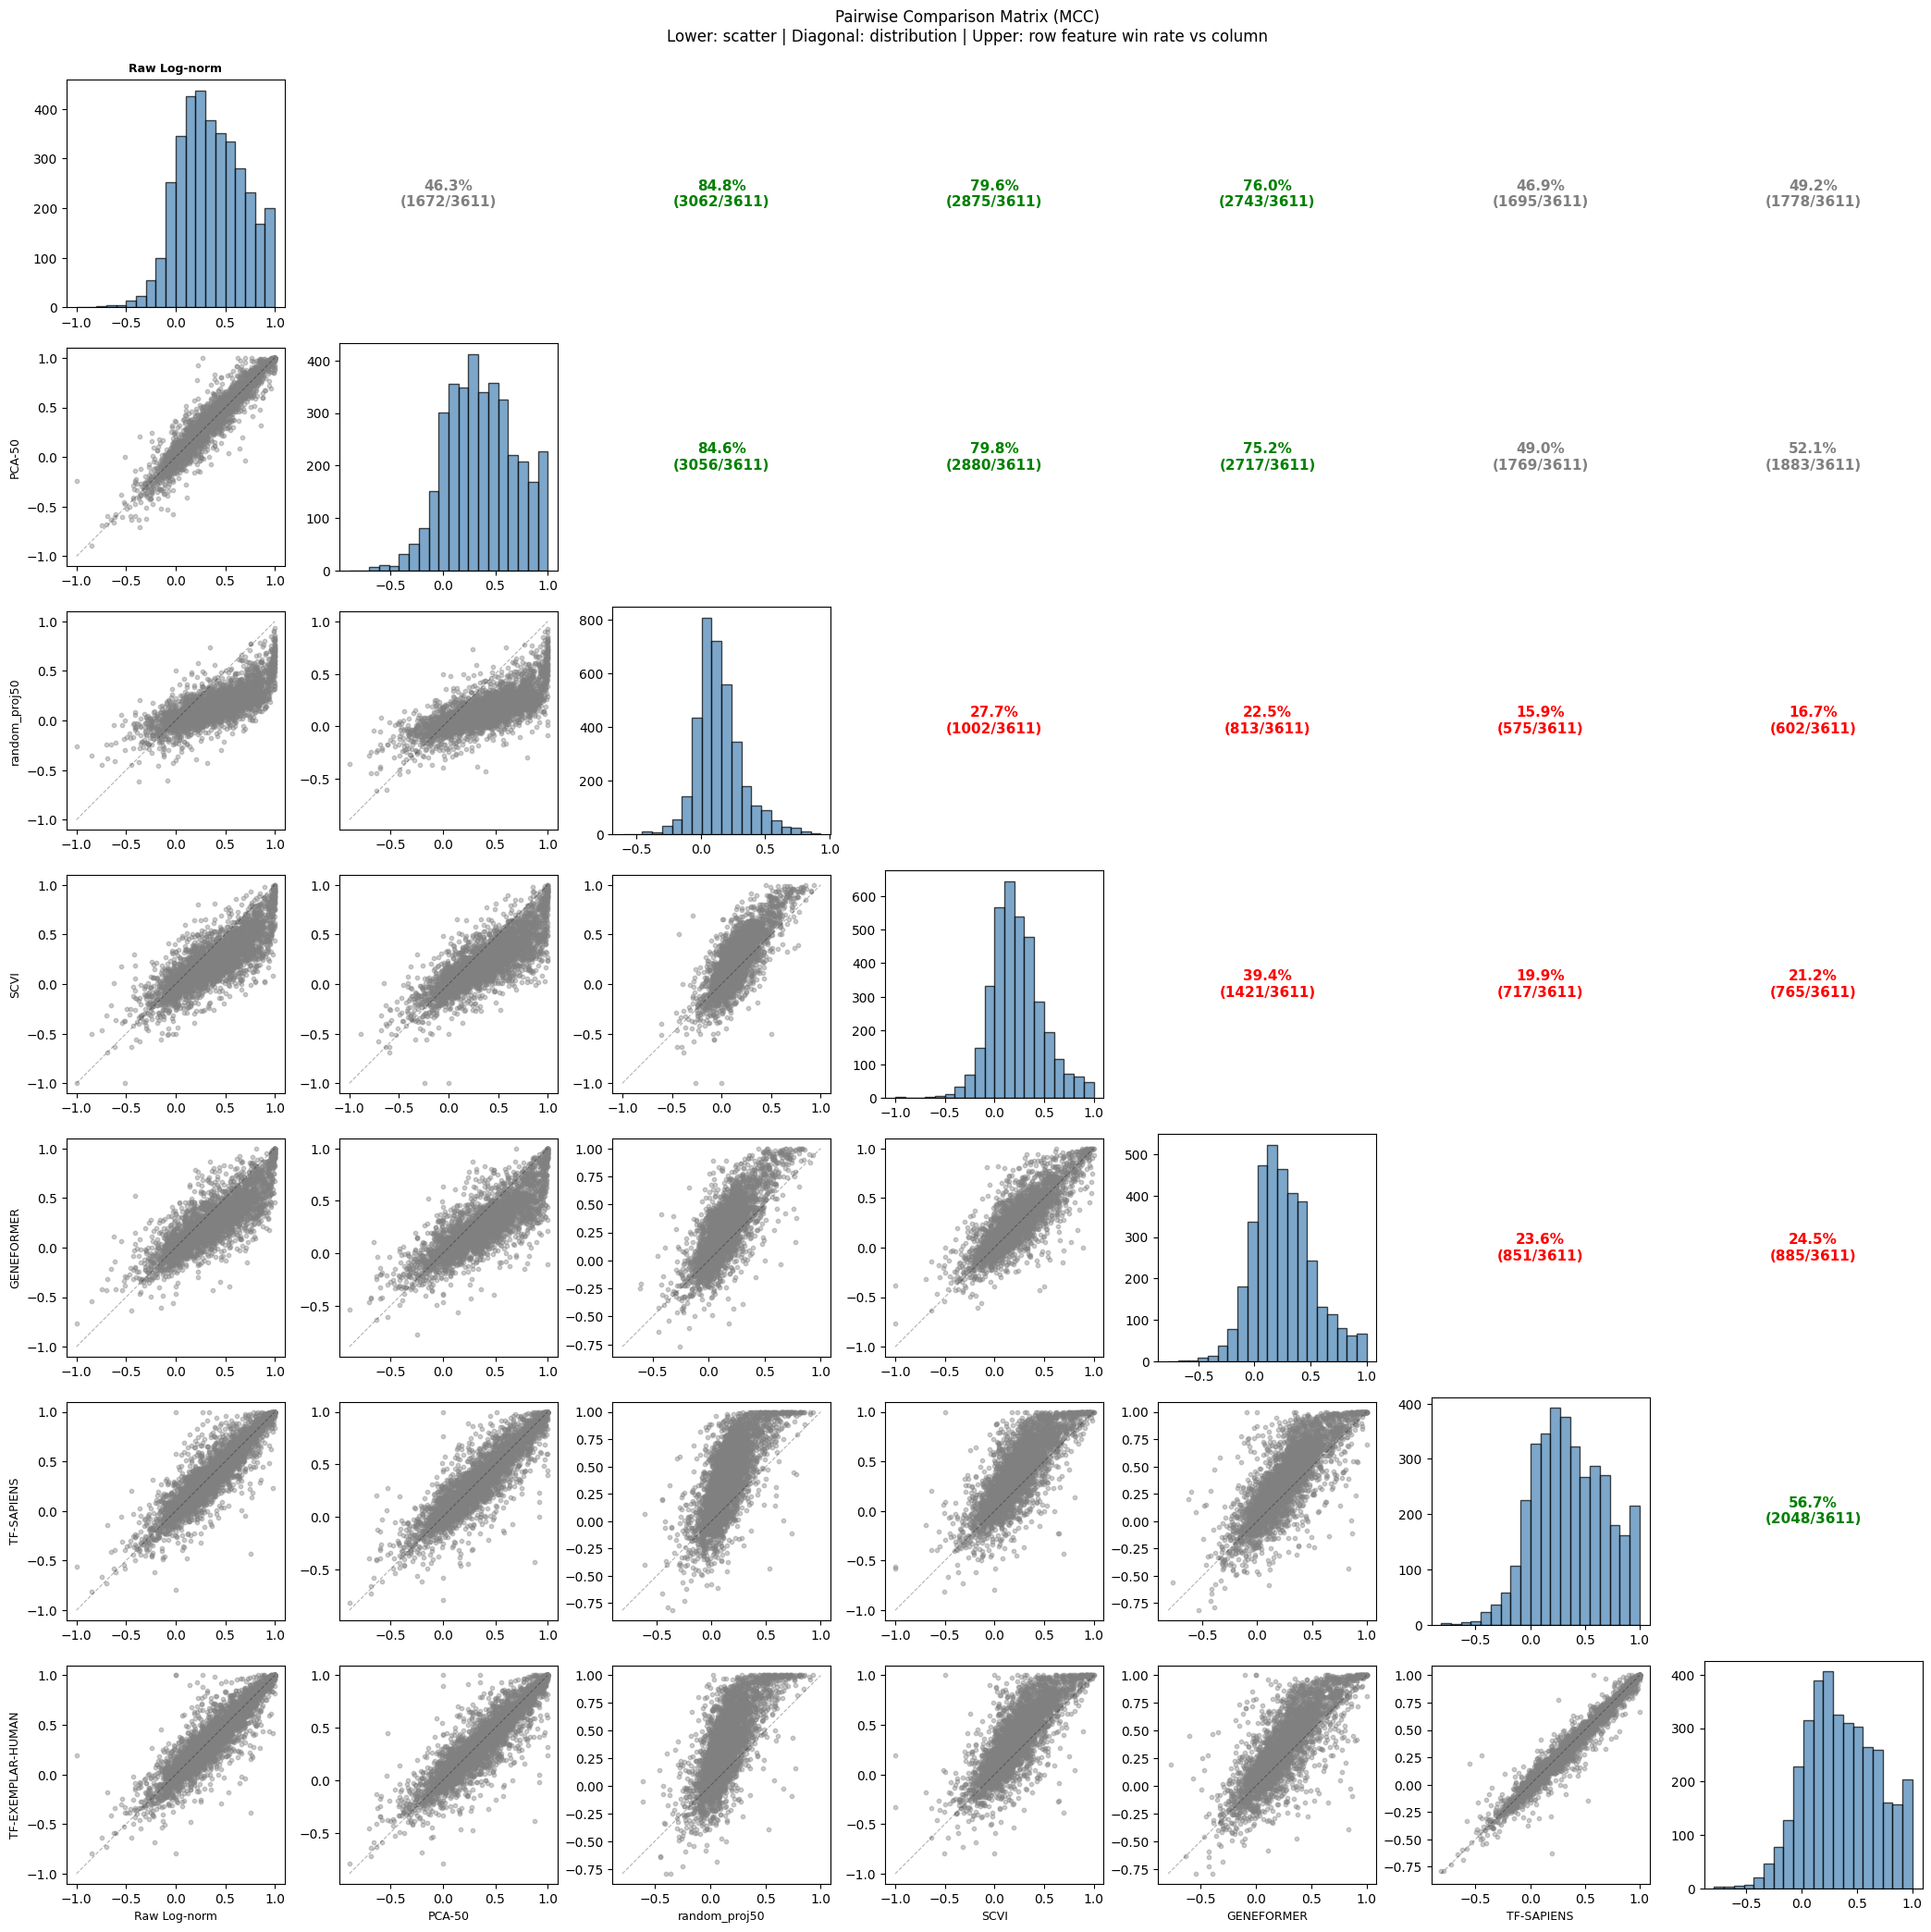

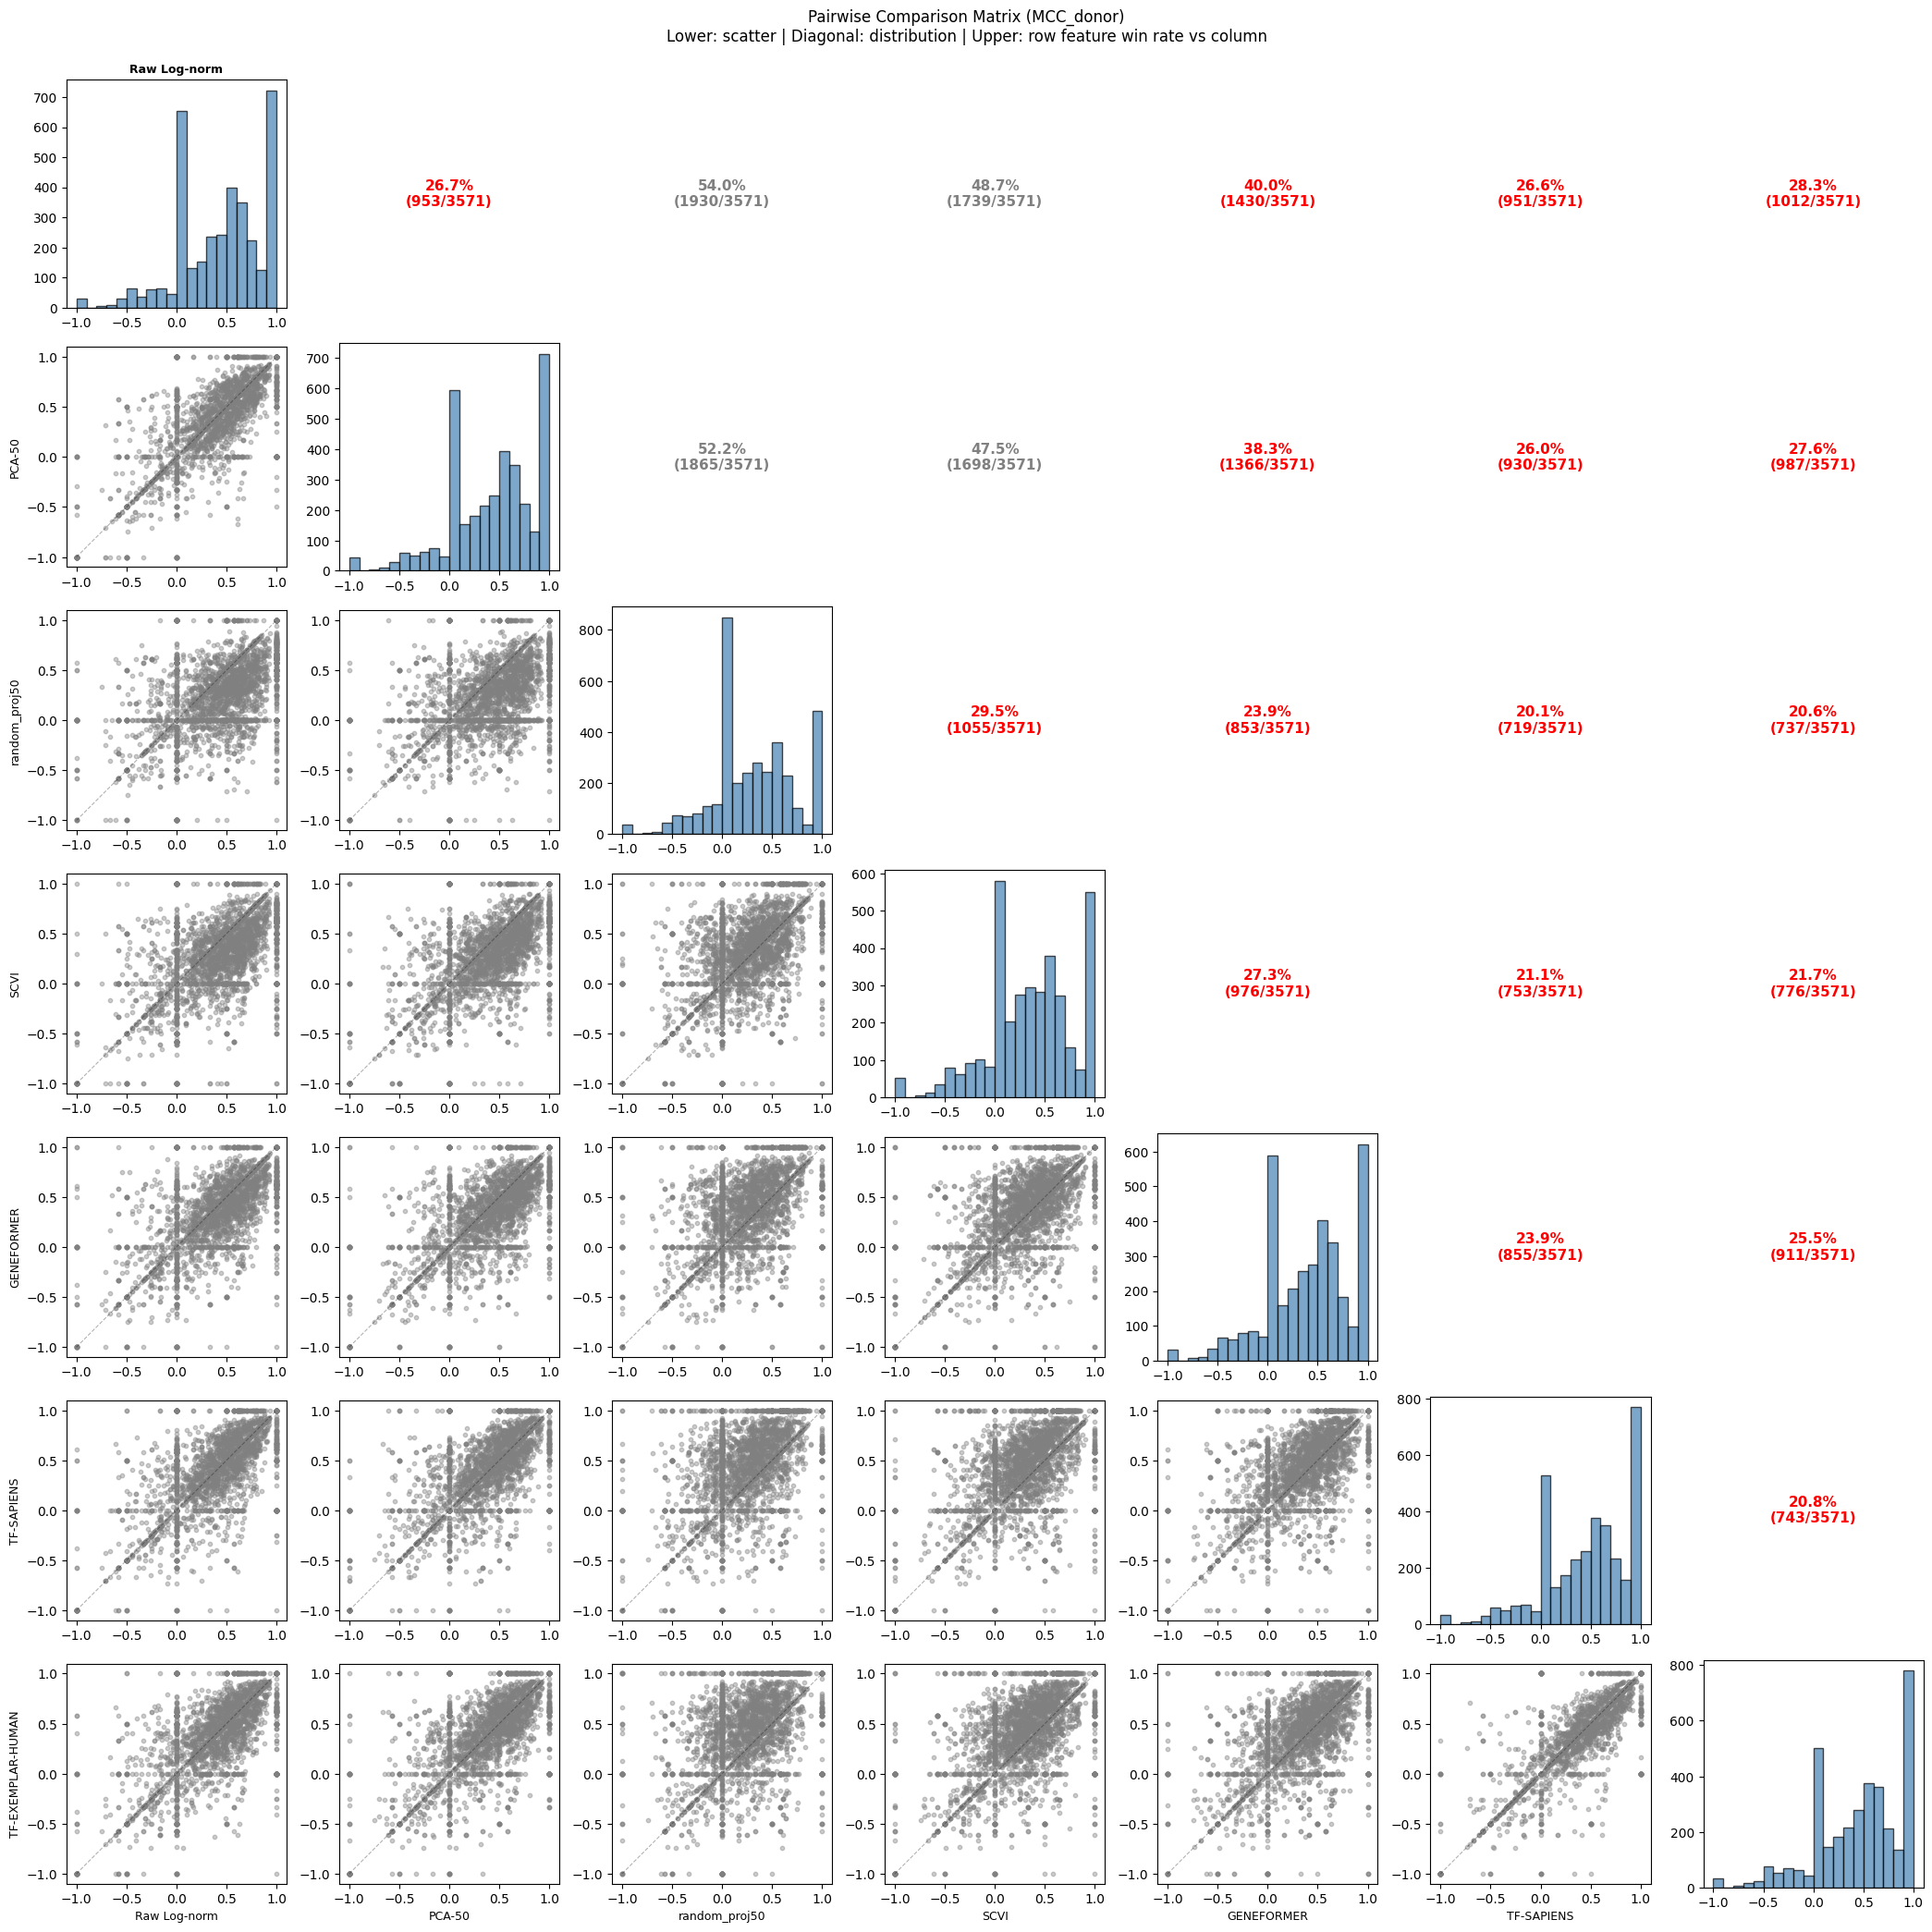

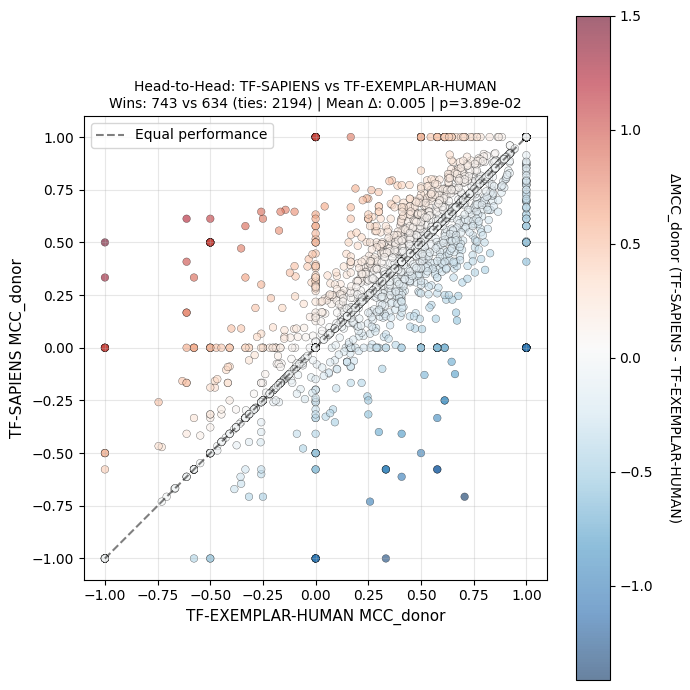

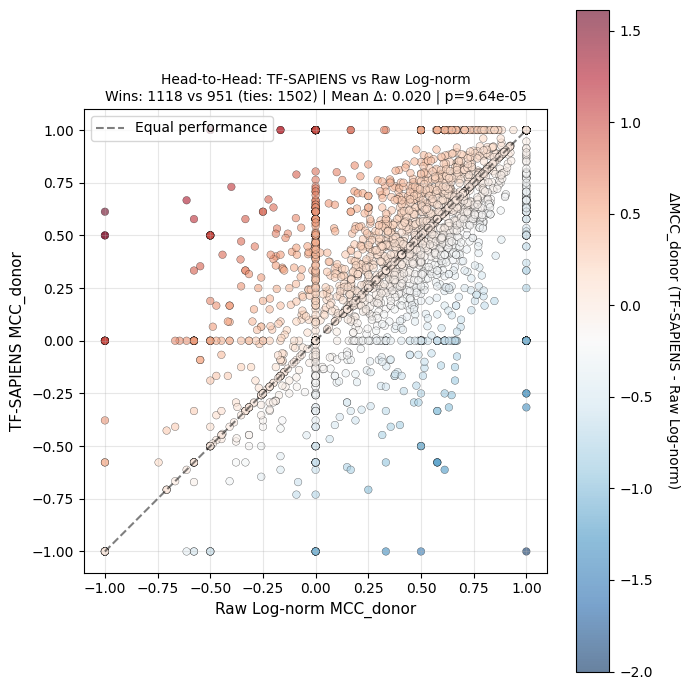

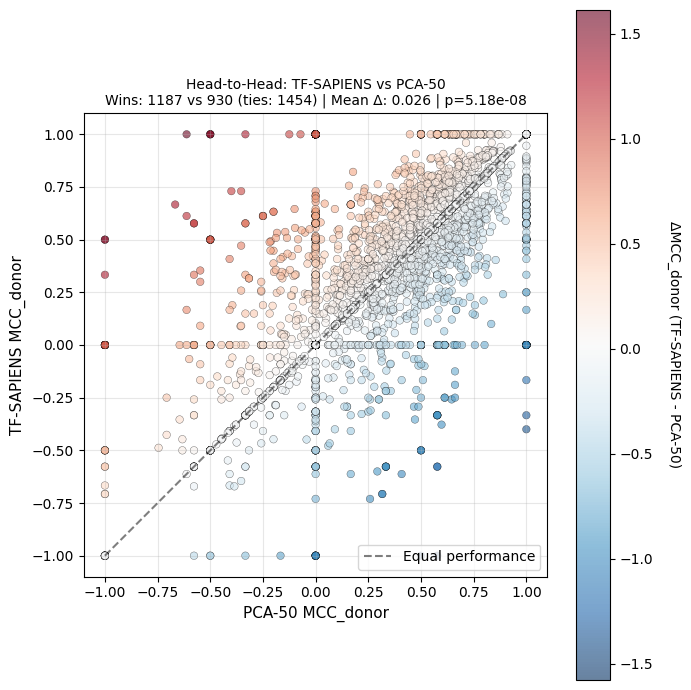

In [18]:
# Load your results
from pathlib import Path

%pdb on
parquet_path = "/Users/dmichael/Downloads/disease_pred_cellxgene/results_1000.parquet"
df = load_and_prepare_results(parquet_path=parquet_path)

print(f"Loaded {len(df)} rows across {df['task_id'].nunique()} tasks")
print(f"Features: {df['feature_clean'].unique().tolist()}")

# 1. Overall performance comparison
fig1 = plot_overall_performance(df)
plt.show()

# 2. Head-to-head: Raw vs best embedding
features = (
    df.groupby("feature_clean")["MCC"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
fig2a = plot_pairwise_comparison(df, features[0], features[1])
fig2b = plot_pairwise_comparison(df, features[0], features[2])
fig2c = plot_pairwise_comparison(df, features[0], features[3])
fig2c = plot_pairwise_comparison(df, features[0], features[4])

# 3. Full comparison matrix
fig3 = plot_comparison_matrix(df, metric="MCC")

# 4. Task variability
# fig4 = plot_task_variability(df, metric="MCC", n_tasks=12)

fig3 = plot_comparison_matrix(df, metric="MCC_donor")
features = (
    df.groupby("feature_clean")["MCC_donor"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
fig2a = plot_pairwise_comparison(df, features[0], features[1], metric="MCC_donor")
fig2b = plot_pairwise_comparison(df, features[0], features[2], metric="MCC_donor")
fig2c = plot_pairwise_comparison(df, features[0], features[3], metric="MCC_donor")

plt.show()

In [20]:
summary = generate_llm_summary(parquet_path, None)

In [21]:
print(summary)

BENCHMARK SUMMARY: DISEASE PREDICTION FROM SINGLE-CELL TRANSCRIPTOMICS

STUDY DESIGN
--------------------------------------------------------------------------------
Task Definition: Predict disease label from single-cell gene expression
Evaluation Strategy: Donor-stratified K-fold cross-validation
  - Unit of splitting: Donor (all cells from one donor stay together)
  - Prevents data leakage from biological replicates
  - Tests generalization to new patients

Scale:
  - Tasks: 861 (dataset × cell_type combinations)
  - Datasets: 82
  - Average folds per task: 4.2
  - Total fold-feature comparisons: 25277

METHODS COMPARED
--------------------------------------------------------------------------------
Baseline Methods (Linear Transformations):
  - Raw_LogNorm: 3611 evaluations
  - Raw_PCA50: 3611 evaluations
  - random_proj50: 3611 evaluations

Foundation Models (Pretrained Embeddings):
  - FM_GENEFORMER: 3611 evaluations
  - FM_SCVI: 3611 evaluations
  - FM_TF-EXEMPLAR-HUMAN: 3611 ev

In [22]:
celltype_results = pd.concat(
    [
        pd.read_parquet(f)
        for f in Path(
            "/Users/dmichael/Downloads/disease_pred_cellxgene/_temp_shards_celltype_1766465049/"
        ).glob("*.parquet")
    ]
)

Loaded 2485 rows across 71 tasks
Features: ['Raw Log-norm', 'PCA-50', 'random_proj50', 'SCVI', 'GENEFORMER', 'TF-SAPIENS', 'TF-EXEMPLAR-HUMAN']


/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1789121523.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1789121523.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/1789121523.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


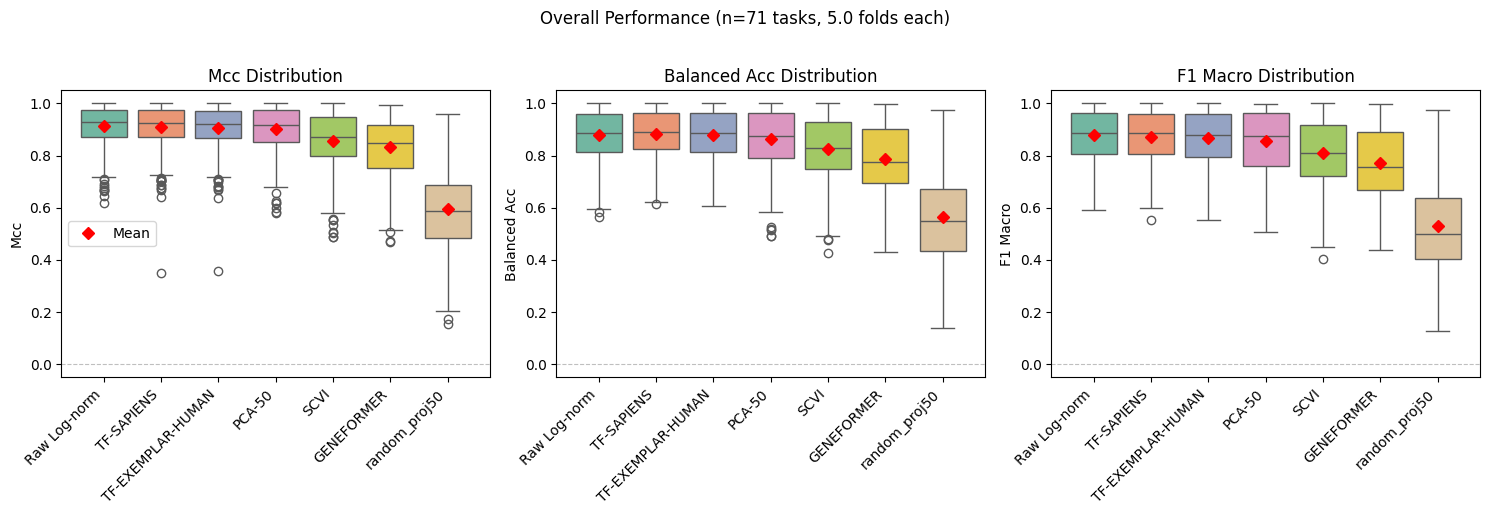

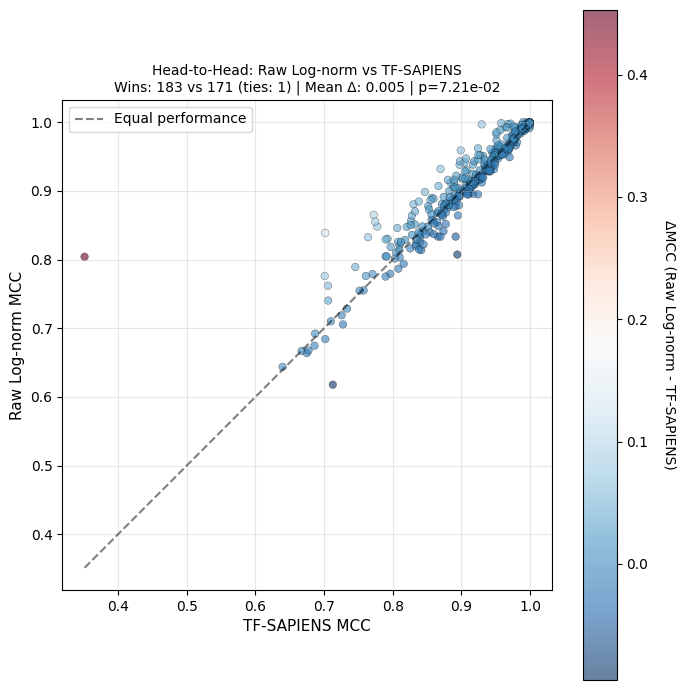

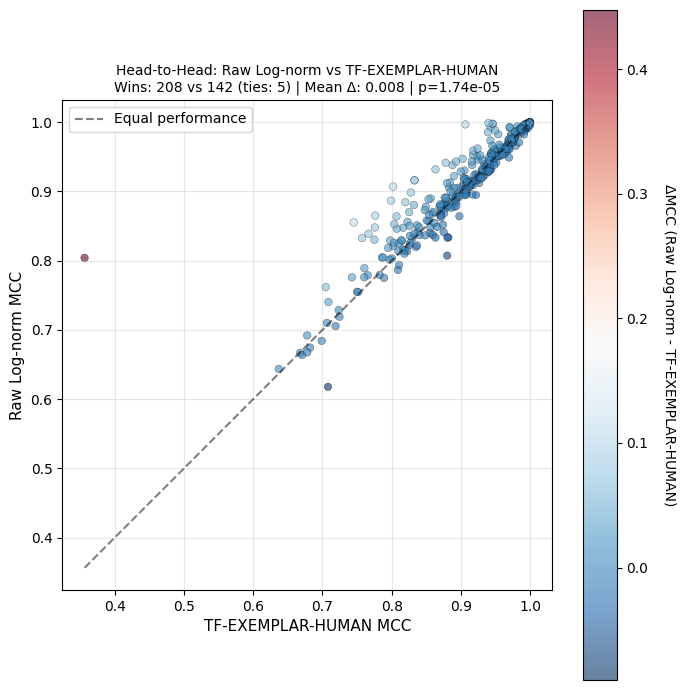

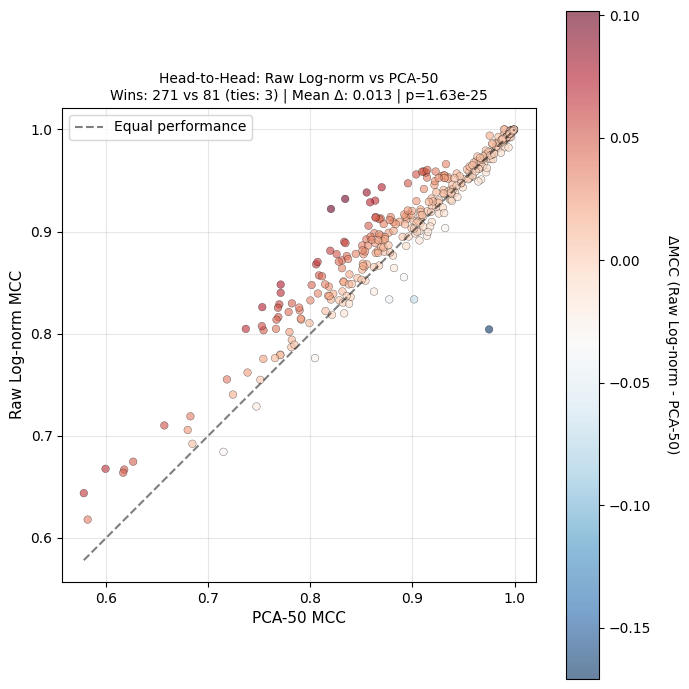

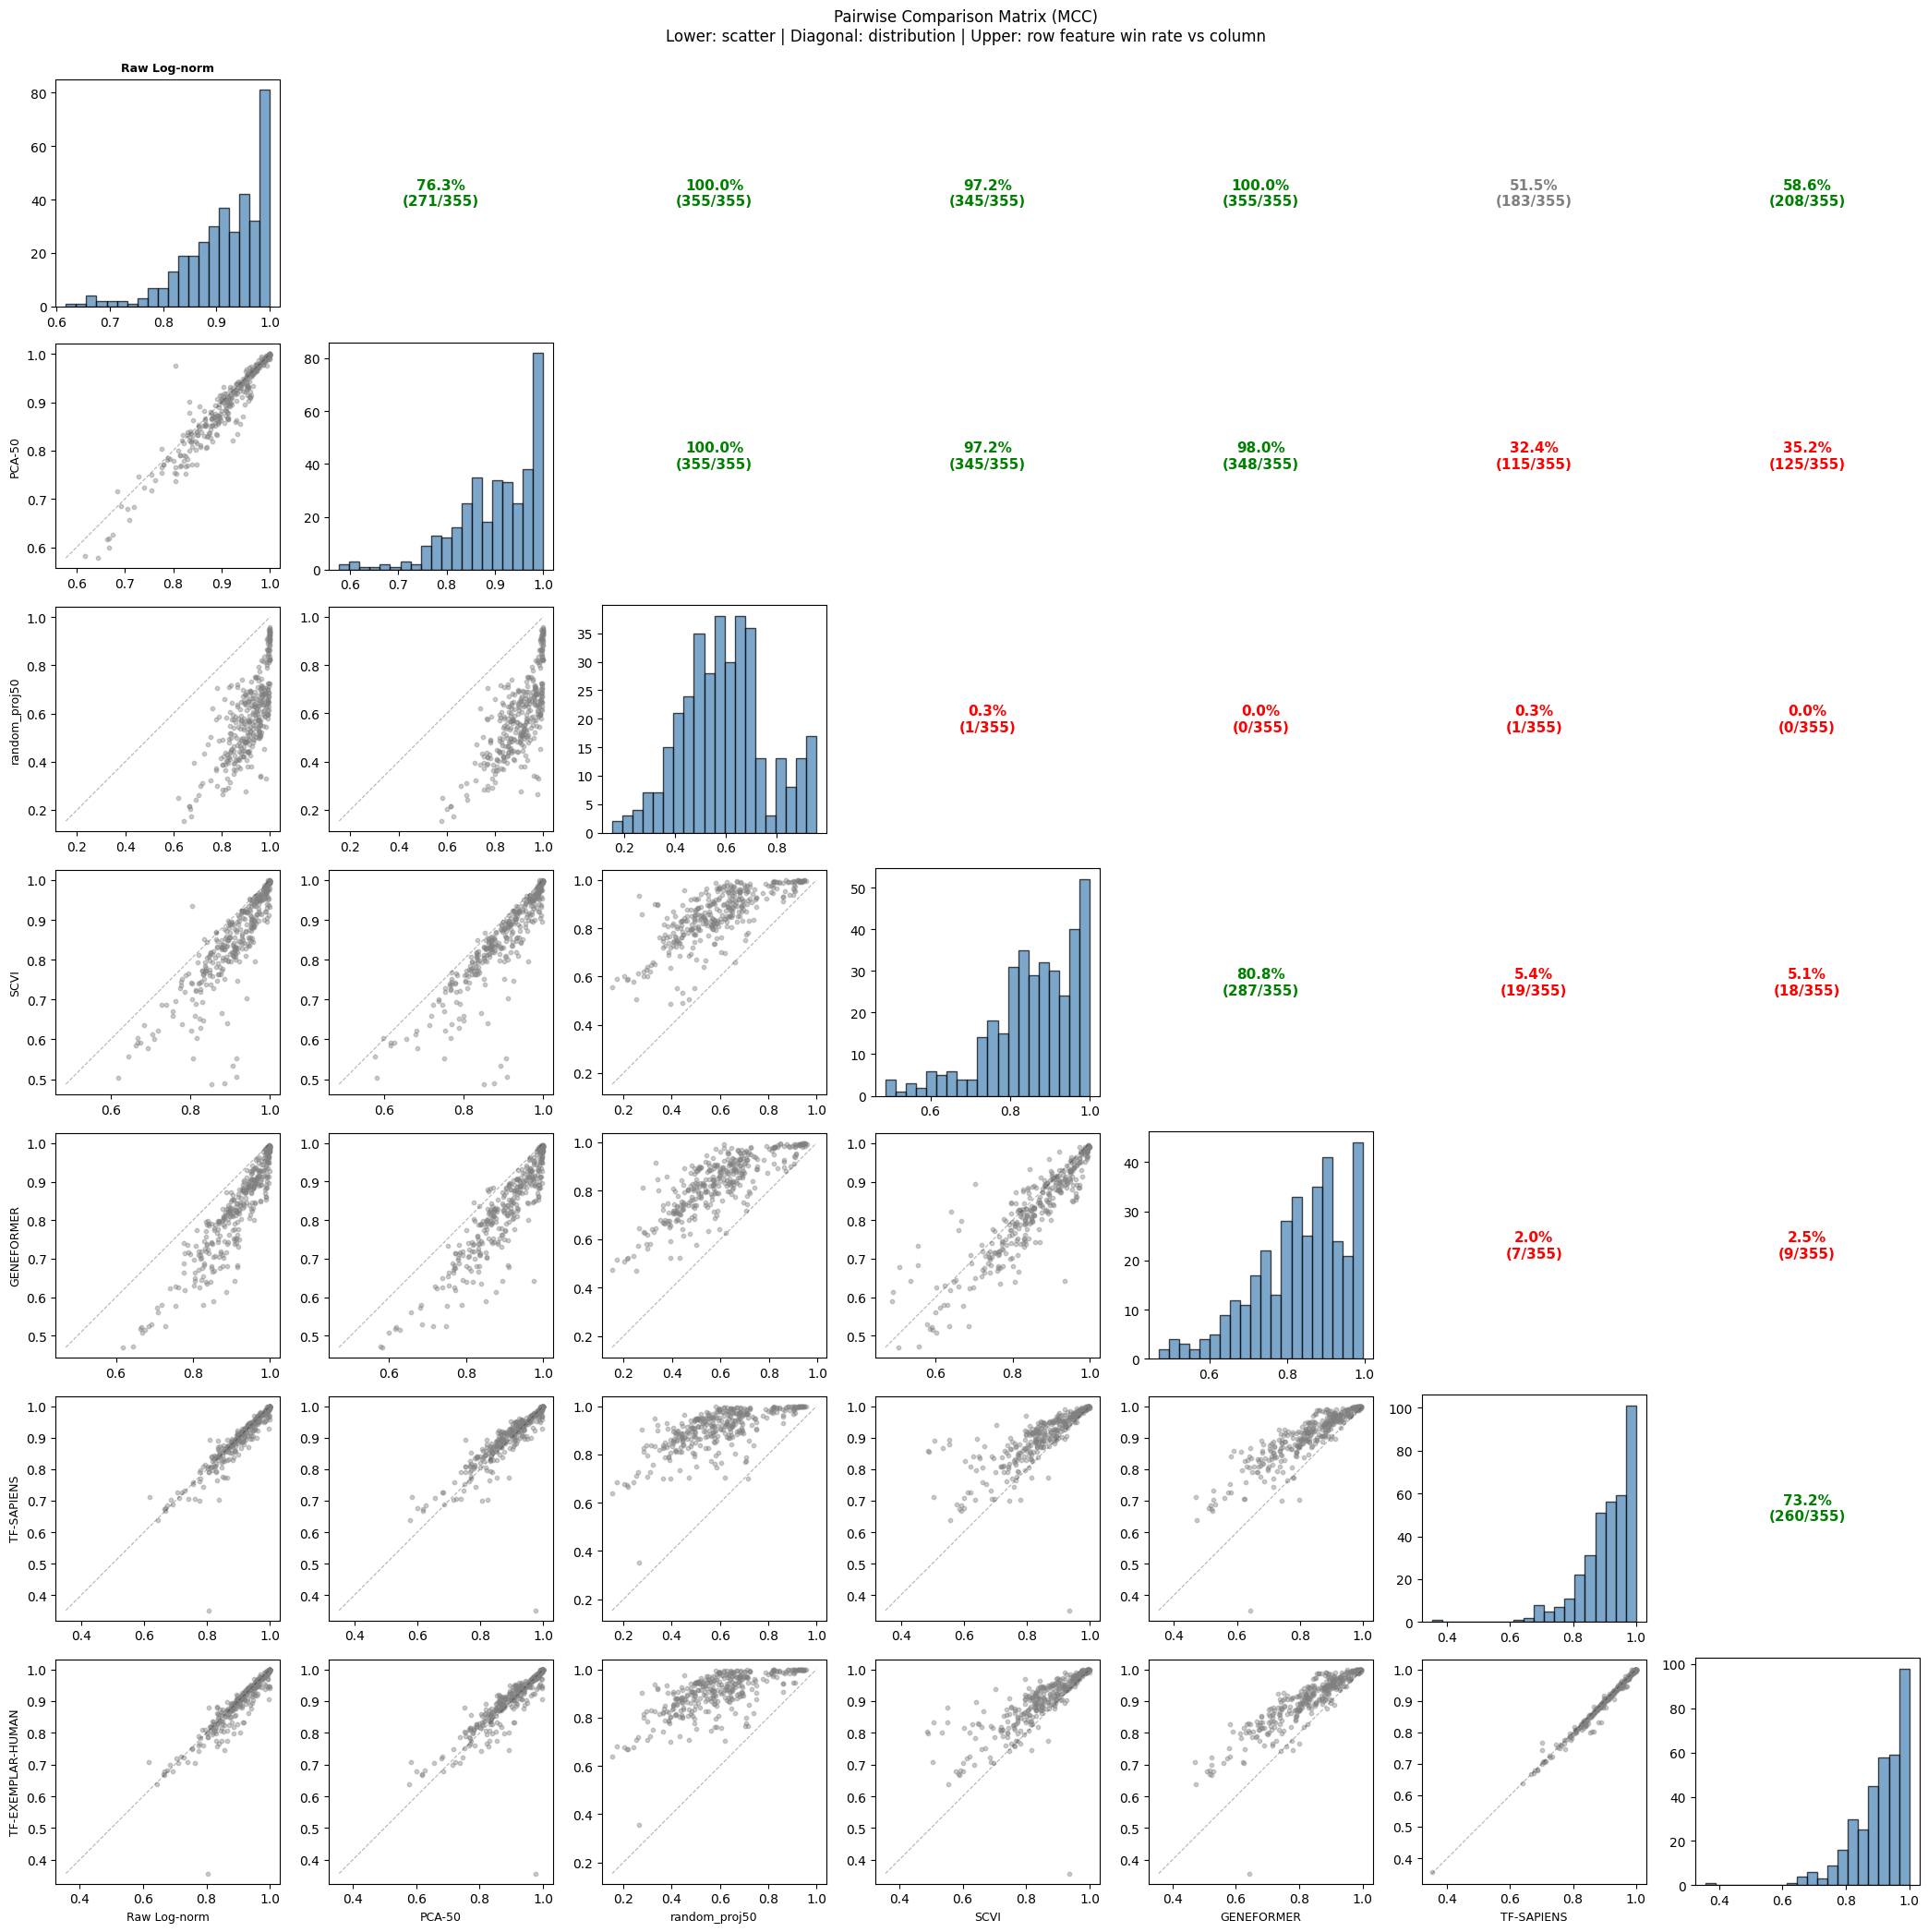

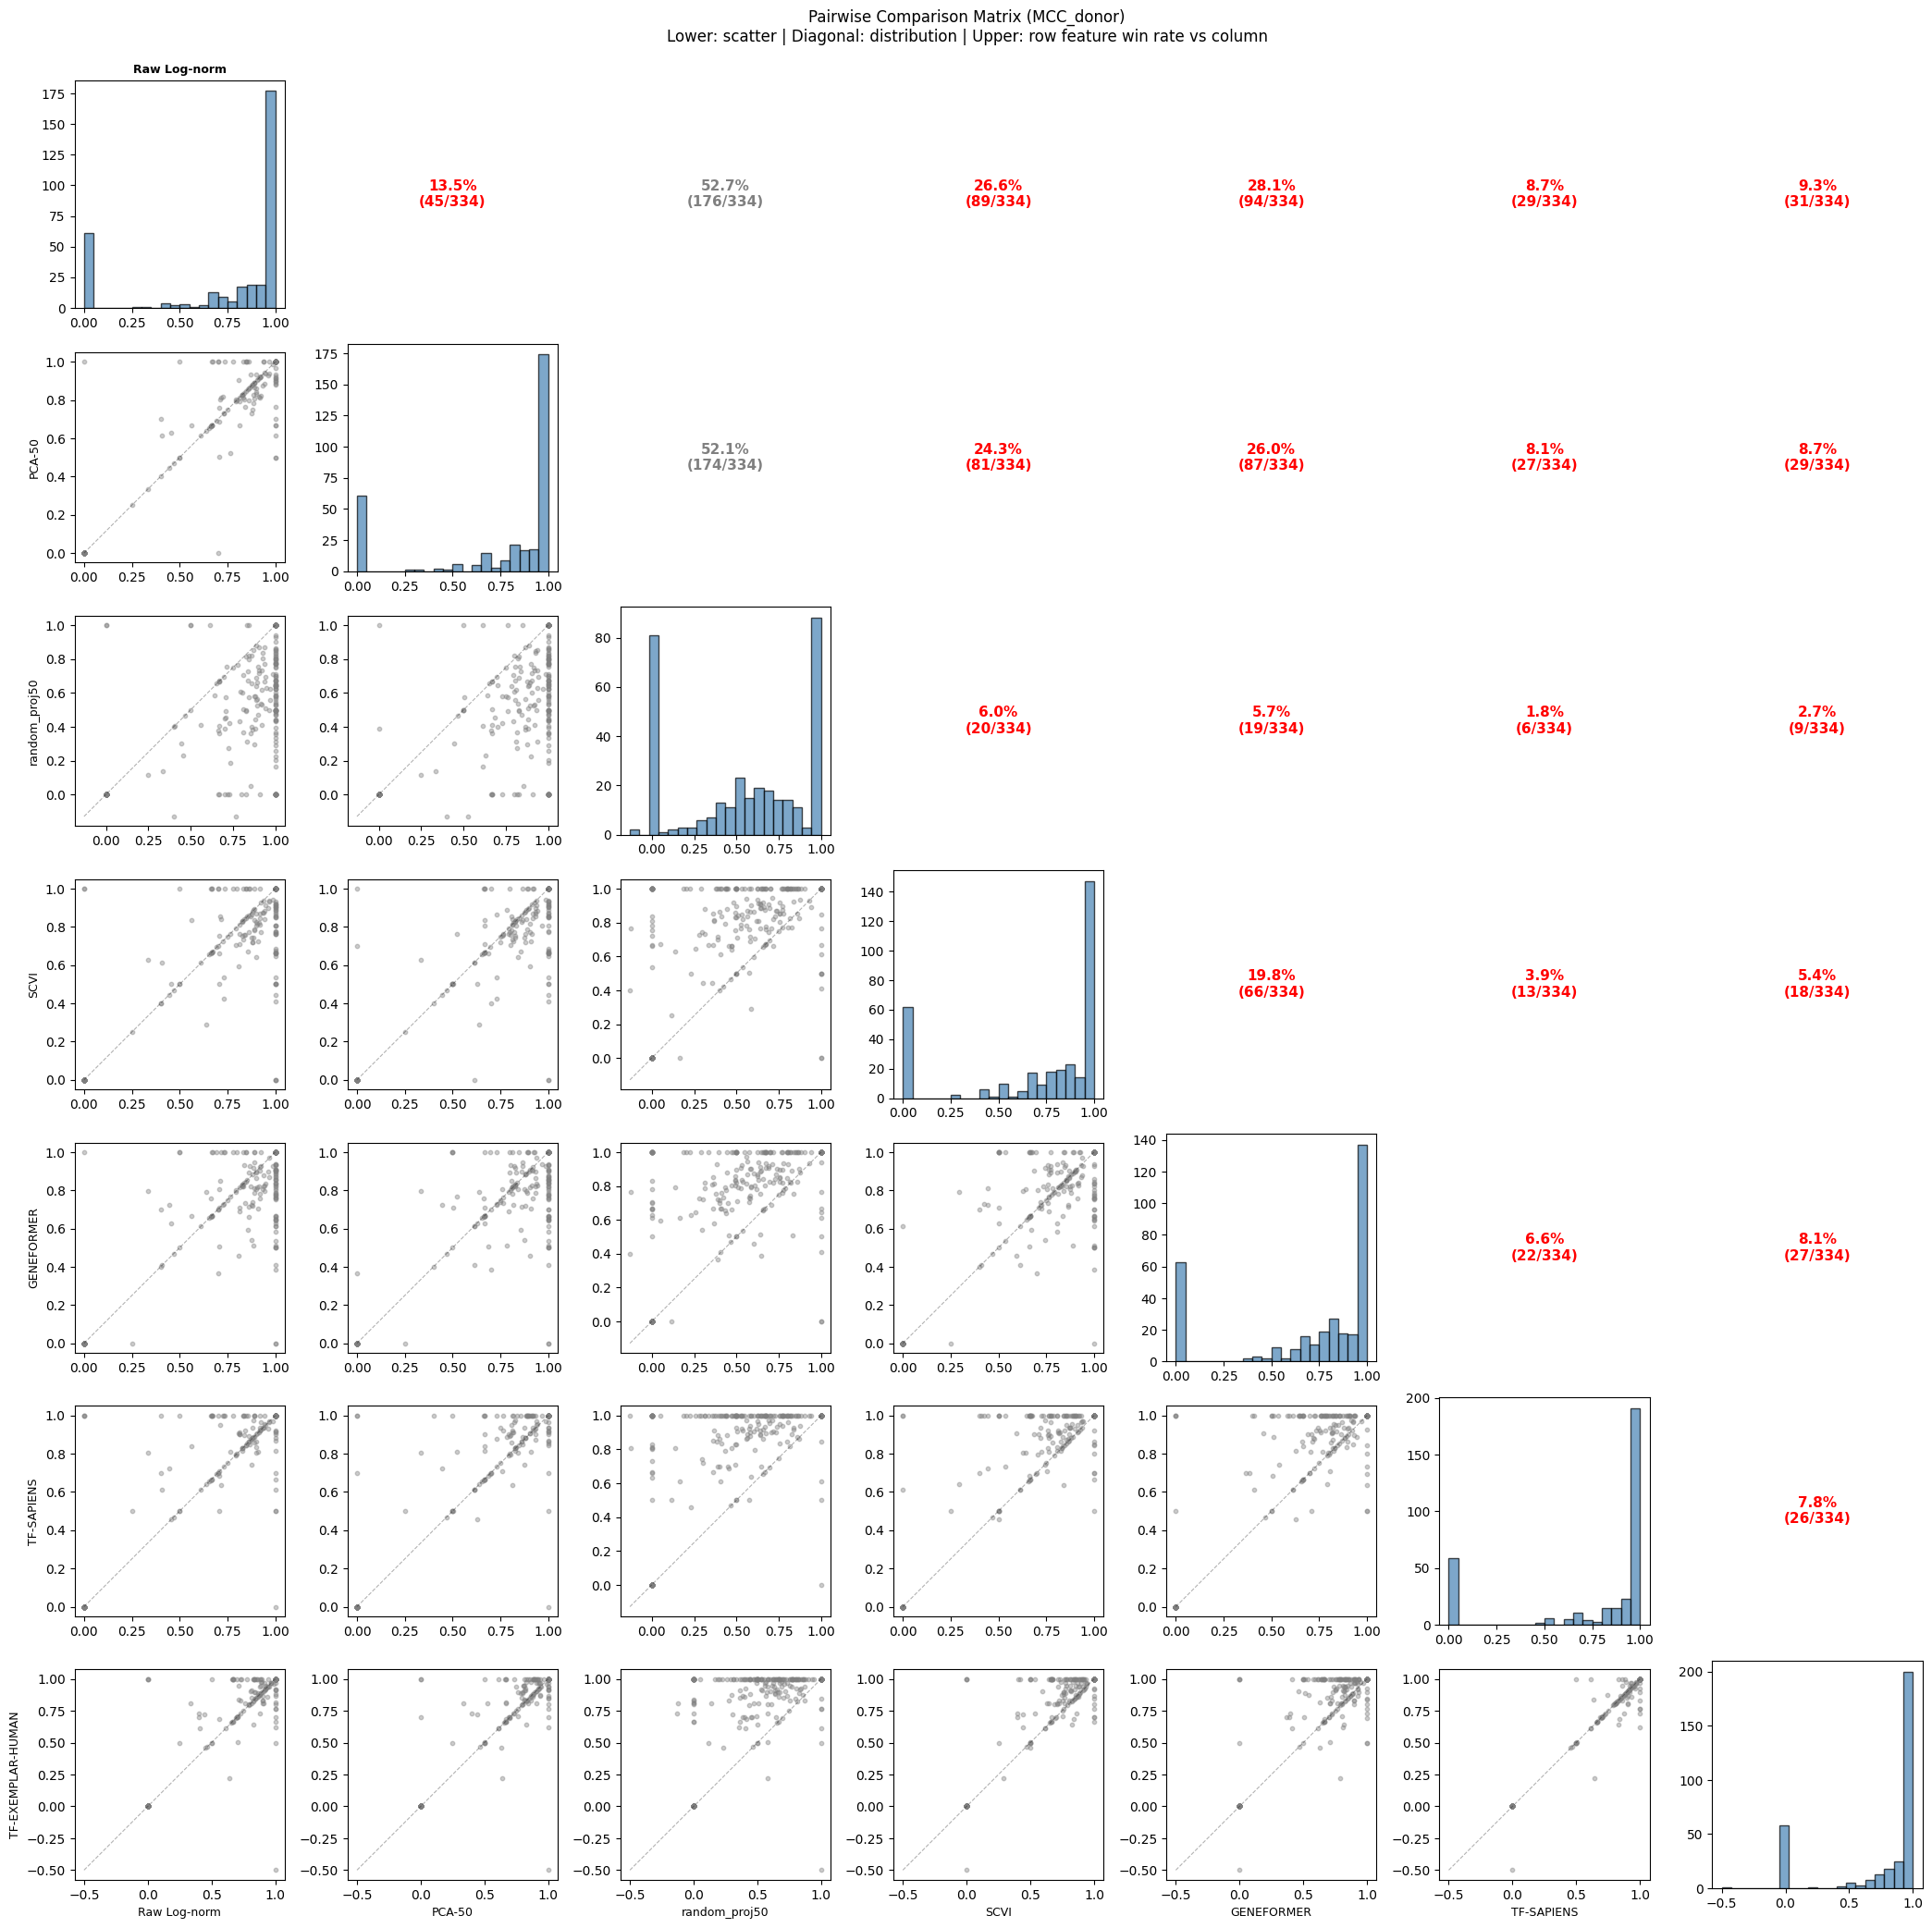

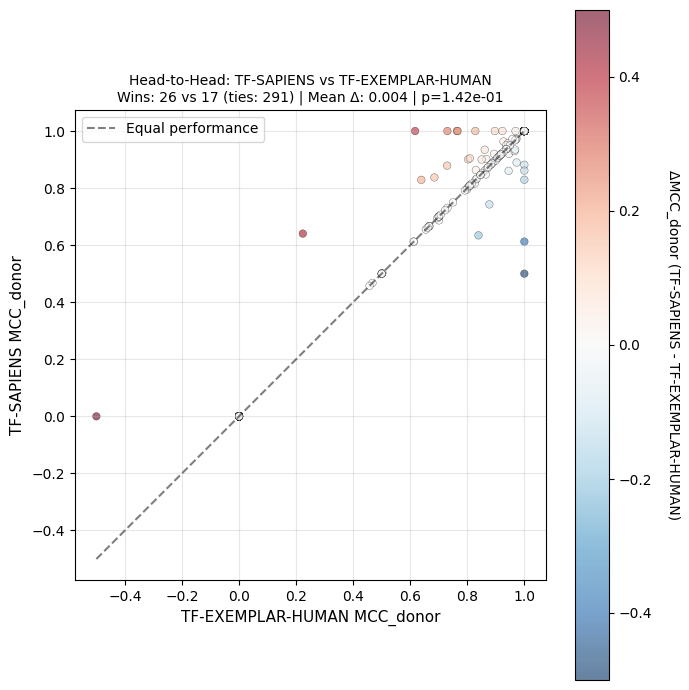

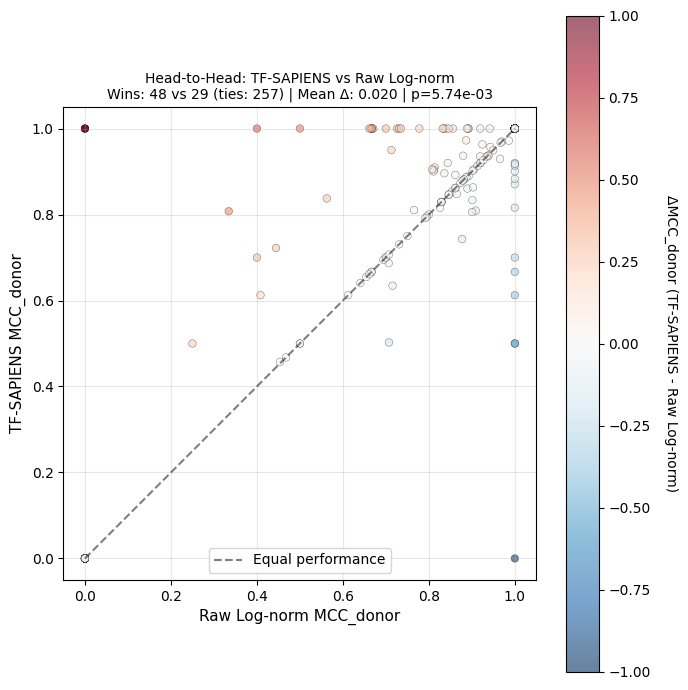

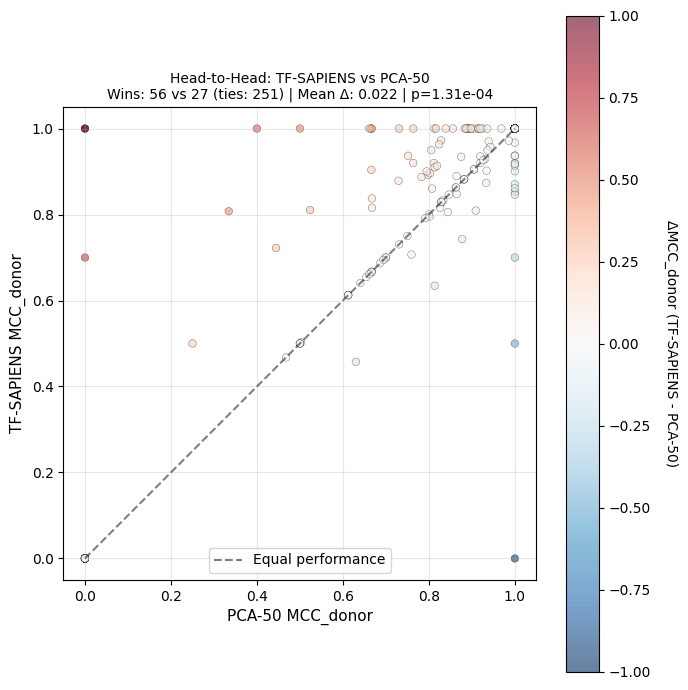

In [23]:
celltype_df = load_and_prepare_results(
    parquet_path="/Users/dmichael/Downloads/disease_pred_cellxgene/celltype_results.parquet"
)

print(f"Loaded {len(celltype_df)} rows across {celltype_df['task_id'].nunique()} tasks")
print(f"Features: {celltype_df['feature_clean'].unique().tolist()}")

# 1. Overall performance comparison
fig1 = plot_overall_performance(celltype_df)
plt.show()

# 2. Head-to-head: Raw vs best embedding
features = (
    celltype_df.groupby("feature_clean")["MCC"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
fig2a = plot_pairwise_comparison(celltype_df, features[0], features[1])
fig2b = plot_pairwise_comparison(celltype_df, features[0], features[2])
fig2c = plot_pairwise_comparison(celltype_df, features[0], features[3])

# 3. Full comparison matrix
fig3 = plot_comparison_matrix(celltype_df, metric="MCC")

# 4. Task variability
# fig4 = plot_task_variability(celltype_df, metric="MCC", n_tasks=12)

fig3 = plot_comparison_matrix(celltype_df, metric="MCC_donor")
features = (
    celltype_df.groupby("feature_clean")["MCC_donor"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
fig2a = plot_pairwise_comparison(
    celltype_df, features[0], features[1], metric="MCC_donor"
)
fig2b = plot_pairwise_comparison(
    celltype_df, features[0], features[2], metric="MCC_donor"
)
fig2c = plot_pairwise_comparison(
    celltype_df, features[0], features[3], metric="MCC_donor"
)

In [25]:
celltype_summary = generate_celltype_summary(
    "/Users/dmichael/Downloads/disease_pred_cellxgene/celltype_results.parquet", None
)
print(celltype_summary)

BENCHMARK SUMMARY: CELL TYPE PREDICTION FROM SINGLE-CELL TRANSCRIPTOMICS

STUDY DESIGN
--------------------------------------------------------------------------------
Task Definition: Predict cell type label from single-cell gene expression
Evaluation Strategy: Donor-stratified K-fold cross-validation
  - Unit of splitting: Donor (all cells from one donor stay together)
  - Prevents data leakage from biological replicates
  - Tests generalization to new patients

CRITICAL: Cell types are taken EXACTLY from disease prediction benchmark.
This enables direct comparison: on the same cells, how do methods perform
for disease prediction vs cell type prediction?

Scale:
  - Tasks: 71 datasets
  - Cell types per task: min=2, median=10, max=35
  - Average folds per task: 5.0
  - Total fold-feature comparisons: 2485

METHODS COMPARED
--------------------------------------------------------------------------------
Baseline Methods (Linear Transformations):
  - Raw_LogNorm: 355 evaluations
  - Ra

In [28]:
adata_kidney = load_or_prepare_adata(
    op_datasets["Diabetic Kidney Disease"],
    census_version="2025-01-30",
    embedding_keys=emb_names,
    census_uri=None,
    cache_dir="/Users/dmichael/bmfm-targets/cache/",
    force_recompute=False,
)

Loading cached dataset from /Users/dmichael/bmfm-targets/cache/dataset_e067e5ca-e53e-485f-aa8e-efd5435229c8_census_2025-01-30.h5ad


In [29]:
kidney_celltype_result = run_cv_experiment(
    adata_kidney,
    n_splits=5,
    train_subsample_frac=1.0,
    skip_incomplete_test_class_support=True,
    # SGD params
    sgd_alpha=1e-5,
    sgd_max_iter=300,
    sgd_tol=1e-3,
    # Split types
    run_donor_holdout=False,
    run_simple_stratified=True,
    # Logging
    log_every_folds=1,
)

[2026-01-13 11:22:36] Start | adata=(20215, 61888) | classes=13 | donors=6 | subsample=1.0
[2026-01-13 11:22:37] Genes ready | X=(20215, 30592) csr float32 | t=0.6s
[2026-01-13 11:22:37] Embeddings | 4 keys: ['geneformer', 'scvi', 'tf-exemplar-human', 'tf-sapiens']
[2026-01-13 11:22:37] 
START SIMPLE STRATIFIED SPLITS
[2026-01-13 11:22:37] 
Simple-stratified fold 0/4 | train=16172 test=4043


/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/2344565977.py:95: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  for k in adata.obsm_keys()


[2026-01-13 11:22:41]      raw_genes_log1p_maxabs | SGD | bACC=0.914 F1w=0.954 | iter=17 | 4.04s
[2026-01-13 11:22:57]   📊 genes_PCA100_train: shape=(16172, 100) | cond=1.97e+00 | range=[-8.81, 8.48]
[2026-01-13 11:22:58]         genes_PCA100_whiten | SGD | bACC=0.916 F1w=0.955 | var=0.189 iter=96 | 17.00s
[2026-01-13 11:22:59]                       RP_50 | SGD | bACC=0.608 F1w=0.702 | iter=131/300 | 1.19s
[2026-01-13 11:22:59]   📊 geneformer_train: shape=(16172, 512) | cond=1.84e+04 | range=[-3.81, 3.31]
[2026-01-13 11:22:59]   📊 geneformer_train_scaled: shape=(16172, 512) | cond=3.61e+03 | range=[-10.26, 9.68]
[2026-01-13 11:23:07]   ⚠️  SGD did NOT converge for geneformer (reached max_iter=300, alpha=5.00e-05)
[2026-01-13 11:23:07]                  geneformer | SGD | bACC=0.835 F1w=0.900 | iter=300/300 α=5.0e-05 | 7.90s
[2026-01-13 11:23:07]   📊 scvi_train: shape=(16172, 50) | cond=1.18e+04 | range=[-2.69, 3.97]
[2026-01-13 11:23:07]   📊 scvi_train_scaled: shape=(16172, 50) | cond=7

/Users/dmichael/.envs/targets/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[2026-01-13 11:23:07]                        scvi | SGD | bACC=0.858 F1w=0.898 | iter=89/300 | 0.55s
[2026-01-13 11:23:08]   📊 tf-exemplar-human_train: shape=(16172, 2048) | cond=4.02e+03 | range=[-2.89, 4.09]
[2026-01-13 11:23:10]   📊 tf-exemplar-human_train_scaled: shape=(16172, 2048) | cond=1.55e+03 | range=[-7.68, 7.72]
[2026-01-13 11:23:16]           tf-exemplar-human | SGD | bACC=0.934 F1w=0.951 | iter=70/300 α=2.0e-05 | 8.66s
[2026-01-13 11:23:17]   📊 tf-sapiens_train: shape=(16172, 2048) | cond=2.84e+03 | range=[-4.66, 2.67]
[2026-01-13 11:23:18]   📊 tf-sapiens_train_scaled: shape=(16172, 2048) | cond=1.13e+03 | range=[-6.67, 7.58]
[2026-01-13 11:23:25]                  tf-sapiens | SGD | bACC=0.935 F1w=0.952 | iter=89/300 α=2.0e-05 | 8.62s
[2026-01-13 11:23:25] 
Simple-stratified fold 1/4 | train=16172 test=4043
[2026-01-13 11:23:28]      raw_genes_log1p_maxabs | SGD | bACC=0.911 F1w=0.953 | iter=14 | 3.62s
[2026-01-13 11:23:45]         genes_PCA100_whiten | SGD | bACC=0.917 F

...

[2026-01-13 11:24:02]                        scvi | SGD | bACC=0.873 F1w=0.901 | iter=106/300 | 0.69s
[2026-01-13 11:24:10]           tf-exemplar-human | SGD | bACC=0.933 F1w=0.953 | iter=96/300 α=2.0e-05 | 8.86s
[2026-01-13 11:24:17]                  tf-sapiens | SGD | bACC=0.930 F1w=0.952 | iter=73/300 α=2.0e-05 | 7.11s
[2026-01-13 11:24:17] 
Simple-stratified fold 2/4 | train=16172 test=4043
[2026-01-13 11:24:22]      raw_genes_log1p_maxabs | SGD | bACC=0.908 F1w=0.951 | iter=17 | 4.03s
[2026-01-13 11:24:37]         genes_PCA100_whiten | SGD | bACC=0.900 F1w=0.949 | var=0.188 iter=103 | 15.75s
[2026-01-13 11:24:39]                       RP_50 | SGD | bACC=0.584 F1w=0.682 | iter=114/300 | 1.31s
[2026-01-13 11:24:53]   ⚠️  SGD did NOT converge for geneformer (reached max_iter=600, alpha=5.00e-05)
[2026-01-13 11:24:53]                  geneformer | SGD | bACC=0.833 F1w=0.896 | iter=600/600 α=5.0e-05 | 14.45s


/Users/dmichael/.envs/targets/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[2026-01-13 11:24:54]                        scvi | SGD | bACC=0.870 F1w=0.901 | iter=111/300 | 0.61s
[2026-01-13 11:25:02]           tf-exemplar-human | SGD | bACC=0.924 F1w=0.946 | iter=83/300 α=2.0e-05 | 8.27s
[2026-01-13 11:25:13]                  tf-sapiens | SGD | bACC=0.924 F1w=0.948 | iter=104/300 α=2.0e-05 | 11.13s
[2026-01-13 11:25:13] 
Simple-stratified fold 3/4 | train=16172 test=4043
[2026-01-13 11:25:17]      raw_genes_log1p_maxabs | SGD | bACC=0.914 F1w=0.954 | iter=17 | 3.74s
[2026-01-13 11:25:34]         genes_PCA100_whiten | SGD | bACC=0.909 F1w=0.954 | var=0.189 iter=97 | 17.57s
[2026-01-13 11:25:36]                       RP_50 | SGD | bACC=0.574 F1w=0.709 | iter=134/300 | 1.19s
[2026-01-13 11:25:57]   ⚠️  SGD did NOT converge for geneformer (reached max_iter=900, alpha=5.00e-05)
[2026-01-13 11:25:57]                  geneformer | SGD | bACC=0.838 F1w=0.893 | iter=900/900 α=5.0e-05 | 21.94s


/Users/dmichael/.envs/targets/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[2026-01-13 11:25:58]                        scvi | SGD | bACC=0.871 F1w=0.901 | iter=95/300 | 0.64s
[2026-01-13 11:26:07]           tf-exemplar-human | SGD | bACC=0.932 F1w=0.957 | iter=73/300 α=2.0e-05 | 8.46s
[2026-01-13 11:26:16]                  tf-sapiens | SGD | bACC=0.928 F1w=0.954 | iter=87/300 α=2.0e-05 | 9.26s
[2026-01-13 11:26:16] 
Simple-stratified fold 4/4 | train=16172 test=4043
[2026-01-13 11:26:19]      raw_genes_log1p_maxabs | SGD | bACC=0.919 F1w=0.954 | iter=15 | 3.48s
[2026-01-13 11:26:37]         genes_PCA100_whiten | SGD | bACC=0.909 F1w=0.952 | var=0.189 iter=113 | 17.56s
[2026-01-13 11:26:38]                       RP_50 | SGD | bACC=0.597 F1w=0.691 | iter=115/300 | 1.27s
[2026-01-13 11:26:55]                  geneformer | SGD | bACC=0.835 F1w=0.894 | iter=678/900 α=5.0e-05 | 16.86s
[2026-01-13 11:26:56]                        scvi | SGD | bACC=0.867 F1w=0.900 | iter=141/300 | 0.66s
[2026-01-13 11:27:04]           tf-exemplar-human | SGD | bACC=0.936 F1w=0.953 |

fold  data_fraction  accuracy  \
split_type        feature                                                 
simple_stratified RP_50                    2.0            1.0  0.696809   
                  geneformer               2.0            1.0  0.894138   
                  scvi                     2.0            1.0  0.898936   
                  genes_PCA100_whiten      2.0            1.0  0.952857   
                  raw_genes_log1p_maxabs   2.0            1.0  0.953104   
                  tf-sapiens               2.0            1.0  0.950779   
                  tf-exemplar-human        2.0            1.0  0.951422   

                                               MCC      bACC  F1_macro  \
split_type        feature                                                
simple_stratified RP_50                   0.629317  0.585949  0.565556   
                  geneformer              0.870481  0.834917  0.832359   
                  scvi                    0.876648  0.868067  0.859309   
                  genes_PCA100_whiten     0.942198  0.910369  0.920376   
                  raw_genes_log1p_maxabs  0.942511  0.913373  0.922781   
                  tf-sapiens              0.939832  0.930290  0.923063   
                  tf-exemplar-human       0.940628  0.931956  0.926097   

                                          F1_micro  F1_weighted  n_nan_preds  \
split_type        feature                                                      
simple_stratified RP_50                   0.696809     0.698481          0.0   
                  geneformer              0.894138     0.895790          0.0   
                  scvi                    0.898936     0.900096          0.0   
                  genes_PCA100_whiten     0.952857     0.953115          0.0   
                  raw_genes_log1p_maxabs  0.953104     0.953301          0.0   
                  tf-sapiens              0.950779     0.951458          0.0   
                  tf-exemplar-human       0.951422     0.952061          0.0   

                                          n_inf_preds  
split_type        feature                              
simple_stratified RP_50                           0.0  
                  geneformer                      0.0  
                  scvi                            0.0  
                  genes_PCA100_whiten             0.0  
                  raw_genes_log1p_maxabs          0.0  
                  tf-sapiens                      0.0  
                  tf-exemplar-human               0.0

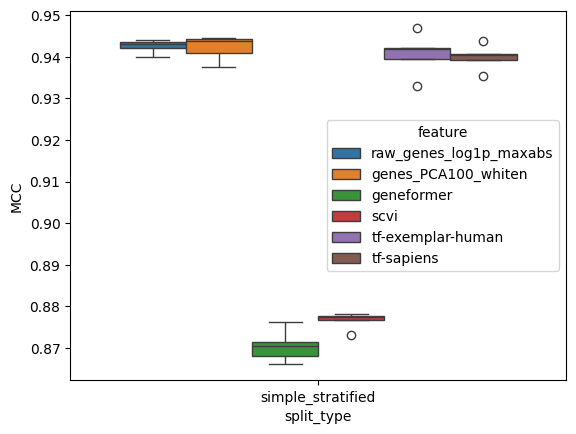

In [30]:
sns.boxplot(
    data=kidney_celltype_result.query('feature != "RP_50"'),
    hue="feature",
    y="MCC",
    x="split_type",
)
kidney_celltype_result.groupby(["split_type", "feature"]).mean(
    numeric_only=True
).sort_values("F1_macro")

In [ ]:
make_umaps_for_obsm(
    adata_hpap,
    reps=("raw", "geneformer", "scvi", "tf-exemplar-human", "tf-sapiens"),
    color_keys=("cell_type", "donor_id"),
    n_neighbors=15,
    min_dist=0.5,
    pca_n_comps=50,
    seed=0,
    save_dir="./umaps",  # or None
    show=True,
)

In [38]:
from cellxgene_census.experimental import (
    get_all_available_embeddings,
    get_all_census_versions_with_embedding,
)

In [39]:
get_all_census_versions_with_embedding("nmf", "homo_sapiens")

['2023-12-15']

In [40]:
[
    *pd.DataFrame(get_all_available_embeddings("2025-01-30"))
    .query("experiment_name=='homo_sapiens'")
    .embedding_name
]

['scvi', 'geneformer', 'tf-sapiens', 'tf-exemplar-human']

In [41]:
[
    *pd.DataFrame(get_all_available_embeddings("2024-07-01"))
    .query("experiment_name=='homo_sapiens'")
    .embedding_name
]

['geneformer', 'scvi', 'scgpt']

In [42]:
[
    *pd.DataFrame(get_all_available_embeddings("2023-12-15"))
    .query("experiment_name=='homo_sapiens' & data_type=='obs_embedding'")
    .embedding_name
]

['scvi', 'geneformer', 'scgpt', 'uce', 'nmf']

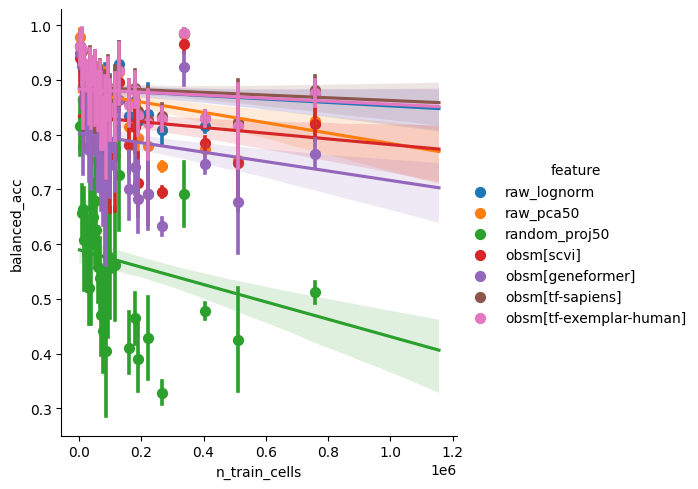

In [43]:
sns.lmplot(
    data=celltype_df, x="n_train_cells", y="balanced_acc", hue="feature", x_bins=30
)
# plt.semilogx()

In [44]:
celltype_df.query('feature in ("raw_lognorm","obsm[geneformer]")').groupby(
    ["dataset_id", "feature"]
).balanced_acc.mean()

dataset_id                            feature         
01ad3cd7-3929-4654-84c0-6db05bd5fd59  obsm[geneformer]    0.831289
                                      raw_lognorm         0.942242
0b75c598-0893-4216-afe8-5414cab7739d  obsm[geneformer]    0.762019
                                      raw_lognorm         0.875054
0bc7235a-ae5a-479d-a487-510435377e55  obsm[geneformer]    0.989081
                                                            ...   
edc8d3fe-153c-4e3d-8be0-2108d30f8d70  raw_lognorm         0.854187
f1606894-59df-4794-a37f-baa7c6fb6de1  obsm[geneformer]    0.842423
                                      raw_lognorm         0.962659
fe4b89d5-461e-440c-a5a8-621b37b122c0  obsm[geneformer]    0.705640
                                      raw_lognorm         0.823111
Name: balanced_acc, Length: 142, dtype: float64

In [45]:
celltype_df[["dataset_id", "fold", "feature", "balanced_acc"]]

,dataset_id,fold,feature,balanced_acc
0,1c739a3e-c3f5-49d5-98e0-73975e751201,0.0,raw_lognorm,0.834539
1,1c739a3e-c3f5-49d5-98e0-73975e751201,0.0,raw_pca50,0.807295
2,1c739a3e-c3f5-49d5-98e0-73975e751201,0.0,random_proj50,0.457734
3,1c739a3e-c3f5-49d5-98e0-73975e751201,0.0,obsm[scvi],0.821343
4,1c739a3e-c3f5-49d5-98e0-73975e751201,0.0,obsm[geneformer],0.699102
...,...,...,...,...
2486,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,4.0,random_proj50,0.401322
2487,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,4.0,obsm[scvi],0.787343
2488,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,4.0,obsm[geneformer],0.734294
2489,edc8d3fe-153c-4e3d-8be0-2108d30f8d70,4.0,obsm[tf-sapiens],0.870006


In [46]:
dataset_ranked = (
    celltype_df.query('feature in ("raw_lognorm","obsm[geneformer]")')
    .groupby(["dataset_id", "feature"])["balanced_acc"]
    .mean()
    .unstack("feature")
    .assign(delta=lambda d: d["obsm[geneformer]"] - d["raw_lognorm"])
    .sort_values("delta", ascending=True)
)

In [47]:
celltype_df.groupby("dataset_id").mean(numeric_only=True).loc[
    dataset_ranked.iloc[:10].index
]

,fold,n_genes,n_cell_types,n_train_cells,n_test_cells,n_train_donors,n_test_donors,n_train_classes,n_test_classes,n_diseased_test_donors,...,std_donor_acc,n_valid_donors,n_cells,n_donors,n_cell_types_found,n_diseases,AUROC,AUPRC,n_tasks,n_folds
dataset_id,,,,,,,,,,,,,,,,,,,,,
e7c5ba7e-4be0-4696-af50-a07d0dc7aac5,2.0,25876.0,23.0,110388.8,27597.2,22.4,5.6,23.0,23.0,1.6,...,0.056792,5.6,NaN,NaN,NaN,NaN,NaN,NaN,71.0,5.0
21d3e683-80a4-4d9b-bc89-ebb2df513dde,2.0,24320.0,12.0,197367.2,49341.8,36.8,9.2,12.0,12.0,6.6,...,0.053717,9.2,NaN,NaN,NaN,NaN,NaN,NaN,71.0,5.0
a12ccb9b-4fbe-457d-8590-ac78053259ef,2.0,35098.0,20.0,242976.8,60744.2,64.0,16.0,20.0,20.0,11.0,...,0.064620,16.0,NaN,NaN,NaN,NaN,NaN,NaN,71.0,5.0
5ce42b38-d867-487f-9b40-e8bb00b21d0b,2.0,24060.0,4.0,53002.4,13250.6,17.6,4.4,4.0,4.0,3.6,...,0.054158,4.4,NaN,NaN,NaN,NaN,NaN,NaN,71.0,5.0
5e717147-0f75-4de1-8bd2-6fda01b8d75f,2.0,25962.0,18.0,69846.4,17461.6,31.2,7.8,18.0,18.0,3.6,...,0.055036,7.8,NaN,NaN,NaN,NaN,NaN,NaN,71.0,5.0
df1edb87-e512-43ae-b5f4-cb179cfc2bb4,2.0,26512.0,12.0,72992.0,18248.0,20.0,5.0,12.0,12.0,2.2,...,0.033337,5.0,NaN,NaN,NaN,NaN,NaN,NaN,71.0,5.0
c7775e88-49bf-4ba2-a03b-93f00447c958,2.0,24645.0,35.0,514036.0,128509.0,96.0,24.0,35.0,35.0,18.2,...,0.073302,24.0,NaN,NaN,NaN,NaN,NaN,NaN,71.0,5.0
2a498ace-872a-4935-984b-1afa70fd9886,2.0,26488.0,25.0,270986.4,67746.6,55.2,13.8,25.0,25.0,6.8,...,0.092204,13.8,NaN,NaN,NaN,NaN,NaN,NaN,71.0,5.0
a37f857c-779f-464e-9310-3db43a1811e7,2.0,24710.0,17.0,160802.4,40200.6,33.6,8.4,17.0,17.0,6.4,...,0.069991,8.4,NaN,NaN,NaN,NaN,NaN,NaN,71.0,5.0


In [48]:
import cellxgene_census
import pandas as pd

# Your collection IDs
collection_ids = [
    "b3e2c6e3-9b05-4da9-8f42-da38a664b45b",  # Diabetic Kidney Disease
    "a3ffde6c-7ad2-498a-903c-d58e732f7470",  # GTEX v9
    "d86517f0-fa7e-4266-b82e-a521350d6d36",  # HypoMap
    "62ef75e4-cbea-454e-a0ce-998ec40223d3",  # Immune Cell Atlas
    "296237e2-393d-4e31-b590-b03f74ac5070",  # Mouse Pancreatic Islet Atlas
    "e5f58829-1a66-40b5-a624-9046778e74f5",  # Tabula Sapiens
]

# Open the Census
census = cellxgene_census.open_soma()

# Get all datasets
census_datasets = census["census_info"]["datasets"].read().concat().to_pandas()

# Filter by your collection IDs
for collection_id in collection_ids:
    datasets = census_datasets[census_datasets["collection_id"] == collection_id]

    if len(datasets) > 0:
        print(f"\nCollection: {datasets.iloc[0]['collection_name']}")
        print(f"Collection ID: {collection_id}")
        print("Dataset IDs:")
        for idx, row in datasets.iterrows():
            print(f"  - {row['dataset_id']} ({row['dataset_title']})")
    else:
        print(f"\nCollection ID: {collection_id} - No datasets found in Census")

census.close()

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.



Collection: Multimodal single cell sequencing implicates chromatin accessibility and genetic background in diabetic kidney disease progression
Collection ID: b3e2c6e3-9b05-4da9-8f42-da38a664b45b
Dataset IDs:
  - e067e5ca-e53e-485f-aa8e-efd5435229c8 (Human kidney cortex snRNA-seq data from donors with and without diabetic kidney disease)

Collection: Single-nucleus cross-tissue molecular reference maps to decipher disease gene function
Collection ID: a3ffde6c-7ad2-498a-903c-d58e732f7470
Dataset IDs:
  - 4ed927e9-c099-49af-b8ce-a2652d069333 (Single-nucleus cross-tissue molecular reference maps to decipher disease gene function)

Collection: HypoMap – a unified single cell gene expression atlas of the murine hypothalamus
Collection ID: d86517f0-fa7e-4266-b82e-a521350d6d36
Dataset IDs:
  - dbb4e1ed-d820-4e83-981f-88ef7eb55a35 (HypoMap – a unified single cell gene expression atlas of the murine hypothalamus)

Collection: Cross-tissue immune cell analysis reveals tissue-specific features in

In [49]:
pv2ad = sc.read_h5ad(
    "/Users/dmichael/.cz-benchmarks/datasets/homo_sapiens_10df7690-6d10-4029-a47e-0f071bb2df83_Prostate_v2_curated.h5ad"
)

In [50]:
pv2_results = run_cv_experiment(
    pv2ad,
    n_splits=5,
    train_subsample_frac=1.0,
    skip_incomplete_test_class_support=True,
    # SGD params
    sgd_alpha=1e-5,
    sgd_max_iter=300,
    sgd_tol=1e-3,
    # Split types
    run_donor_holdout=False,
    run_simple_stratified=True,
    # Logging
    log_every_folds=1,
)

[2026-01-13 13:11:03] Filtering 1 rare classes (<5 cells): {'T cell': 1}
[2026-01-13 13:11:03]   Remaining: 2043 cells, 13 classes
[2026-01-13 13:11:03] Start | adata=(2043, 21808) | classes=13 | donors=1 | subsample=1.0
[2026-01-13 13:11:03] Genes ready | X=(2043, 21808) csr float32 | t=0.2s
[2026-01-13 13:11:03] Embeddings | 6 keys: ['X_pca', 'X_scvi', 'X_umap', 'X_umap_scvi_full_donorassay', 'X_uncorrected_alltissues_umap', 'X_uncorrected_umap']
[2026-01-13 13:11:03] 
START SIMPLE STRATIFIED SPLITS
[2026-01-13 13:11:03] 
Simple-stratified fold 0/4 | train=1634 test=409


/var/folders/xt/l7g716w17kb53w9c8khg3j_80000gn/T/ipykernel_97784/2344565977.py:95: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  for k in adata.obsm_keys()


[2026-01-13 13:11:03]      raw_genes_log1p_maxabs | SGD | bACC=0.923 F1w=0.965 | iter=11 | 0.41s
[2026-01-13 13:11:06]   📊 genes_PCA100_train: shape=(1634, 100) | cond=3.32e+00 | range=[-13.88, 16.18]
[2026-01-13 13:11:06]         genes_PCA100_whiten | SGD | bACC=0.935 F1w=0.970 | var=0.477 iter=35 | 2.35s
[2026-01-13 13:11:06]                       RP_50 | SGD | bACC=0.780 F1w=0.861 | iter=80/300 | 0.19s
[2026-01-13 13:11:06]   📊 X_pca_train: shape=(1634, 50) | cond=1.06e+02 | range=[-143.73, 132.79]
[2026-01-13 13:11:06]   📊 X_pca_train_scaled: shape=(1634, 50) | cond=5.99e+01 | range=[-24.24, 23.85]
[2026-01-13 13:11:06]                       X_pca | SGD | bACC=0.957 F1w=0.970 | iter=54/300 | 0.16s
[2026-01-13 13:11:06]   📊 X_scvi_train: shape=(1634, 50) | cond=3.95e+02 | range=[-4.69, 4.86]
[2026-01-13 13:11:06]   📊 X_scvi_train_scaled: shape=(1634, 50) | cond=4.61e+01 | range=[-5.43, 4.43]
[2026-01-13 13:11:06]                      X_scvi | SGD | bACC=0.932 F1w=0.963 | iter=69/300

fold  data_fraction  \
split_type        feature                                              
simple_stratified X_uncorrected_alltissues_umap   2.0            1.0   
                  X_uncorrected_umap              2.0            1.0   
                  X_umap                          2.0            1.0   
                  X_umap_scvi_full_donorassay     2.0            1.0   
                  RP_50                           2.0            1.0   
                  raw_genes_log1p_maxabs          2.0            1.0   
                  X_scvi                          2.0            1.0   
                  genes_PCA100_whiten             2.0            1.0   
                  X_pca                           2.0            1.0   

                                                 accuracy       MCC      bACC  \
split_type        feature                                                       
simple_stratified X_uncorrected_alltissues_umap  0.733007  0.711191  0.593933   
                  X_uncorrected_umap             0.840587  0.820747  0.752588   
                  X_umap                         0.835697  0.820730  0.763636   
                  X_umap_scvi_full_donorassay    0.835697  0.820730  0.763636   
                  RP_50                          0.841565  0.821712  0.779425   
                  raw_genes_log1p_maxabs         0.965281  0.960878  0.913252   
                  X_scvi                         0.951589  0.945512  0.926573   
                  genes_PCA100_whiten            0.968704  0.964735  0.918412   
                  X_pca                          0.961858  0.957040  0.939951   

                                                 F1_macro  F1_micro  \
split_type        feature                                             
simple_stratified X_uncorrected_alltissues_umap  0.562398  0.733007   
                  X_uncorrected_umap             0.747217  0.840587   
                  X_umap                         0.754374  0.835697   
                  X_umap_scvi_full_donorassay    0.754374  0.835697   
                  RP_50                          0.768534  0.841565   
                  raw_genes_log1p_maxabs         0.914067  0.965281   
                  X_scvi                         0.916003  0.951589   
                  genes_PCA100_whiten            0.919930  0.968704   
                  X_pca                          0.929106  0.961858   

                                                 F1_weighted  n_nan_preds  \
split_type        feature                                                   
simple_stratified X_uncorrected_alltissues_umap     0.684441          0.0   
                  X_uncorrected_umap                0.826335          0.0   
                  X_umap                            0.834960          0.0   
                  X_umap_scvi_full_donorassay       0.834960          0.0   
                  RP_50                             0.845198          0.0   
                  raw_genes_log1p_maxabs            0.962856          0.0   
                  X_scvi                            0.953699          0.0   
                  genes_PCA100_whiten               0.965729          0.0   
                  X_pca                             0.962634          0.0   

                                                 n_inf_preds  
split_type        feature                                     
simple_stratified X_uncorrected_alltissues_umap          0.0  
                  X_uncorrected_umap                     0.0  
                  X_umap                                 0.0  
                  X_umap_scvi_full_donorassay            0.0  
                  RP_50                                  0.0  
                  raw_genes_log1p_maxabs                 0.0  
                  X_scvi                                 0.0  
                  genes_PCA100_whiten                    0.0  
                  X_pca                                  0.0

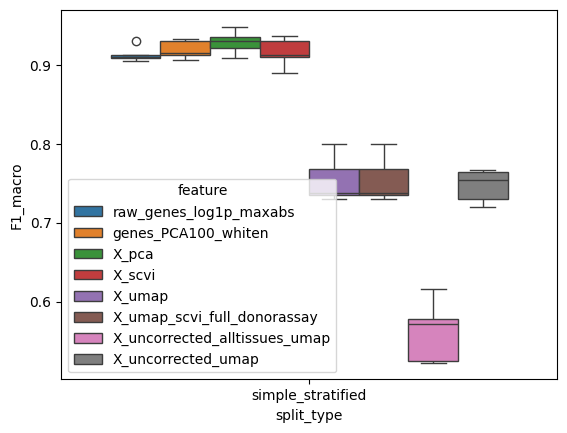

In [51]:
sns.boxplot(
    data=pv2_results.query('feature != "RP_50"'),
    hue="feature",
    y="F1_macro",
    x="split_type",
)
pv2_results.groupby(["split_type", "feature"]).mean(numeric_only=True).sort_values(
    "F1_macro"
)